# Multi-concept alignment

Initial analysis of how CAV alignment and artifact localization change as the nested attacked CelebA concept set grows from $K=1$ to $K=5$.


In [14]:
from collections.abc import Sequence
from pathlib import Path
import json
import math
import re

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


## Context & methods


The notebook reads each signed run manifest and its summary CSVs. Every visualization puts a deduplicated Baseline column first, followed by one Orthogonal column per selected alpha. The first three trend sections end with an overview row that averages the concepts available at each $K$. Localization uses raw masks by default, and uncertainty bands show ±1 SEM across evaluation samples.


In [15]:
def find_project_root(start: Path | None = None) -> Path:
    start = (Path.cwd() if start is None else Path(start)).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "notebooks").is_dir() and (candidate / "results").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current directory.")


PROJECT_ROOT = find_project_root()
RESULTS_ROOT = PROJECT_ROOT / "results" / "multi_concept_alignment"
MEDIA_ROOT = PROJECT_ROOT / "media" / "multi_concept_alignment"
MEDIA_ROOT.mkdir(parents=True, exist_ok=True)

CONCEPT_ORDER = ("timestamp", "box", "brightness", "checkerboard", "watermark")
LOCALIZED_CONCEPT_ORDER = tuple(c for c in CONCEPT_ORDER if c != "brightness")
ACTIVE_CONCEPT_AVERAGE = "active_concept_average"
LOCALIZABLE_CONCEPT_AVERAGE = "localizable_concept_average"
CAV_METHOD_ORDER = (
    "pattern_cav",
    "multi_cav",
    "svm_cav",
    "log_cav",
    "random_cav",
    "ridge_cav",
)
ALPHA_ORDER = (0.01, 0.1, 1.0, 10.0)

CONCEPT_LABELS = {
    "timestamp": "Timestamp",
    "box": "Box",
    "brightness": "Brightness",
    "checkerboard": "Checkerboard",
    "watermark": "Watermark",
    ACTIVE_CONCEPT_AVERAGE: "Active-concept average",
    LOCALIZABLE_CONCEPT_AVERAGE: "Localizable-concept average",
}
METHOD_LABELS = {
    "pattern_cav": "Pattern CAV",
    "multi_cav": "Multi CAV",
    "svm_cav": "SVM CAV",
    "log_cav": "Logistic CAV",
    "ridge_cav": "Ridge CAV",
    "random_cav": "Random CAV",
}
# Match concept_alignment.ipynb: common methods follow Matplotlib tab10 order.
# Ridge is the additional sixth method and therefore uses the next tab10 color.
METHOD_COLORS = {
    "pattern_cav": "#1f77b4",  # tab:blue
    "multi_cav": "#ff7f0e",    # tab:orange
    "svm_cav": "#2ca02c",      # tab:green
    "log_cav": "#d62728",      # tab:red
    "random_cav": "#9467bd",   # tab:purple
    "ridge_cav": "#8c564b",    # tab:brown
}
METHOD_MARKERS = {
    "pattern_cav": "o",
    "multi_cav": "s",
    "svm_cav": "^",
    "log_cav": "D",
    "ridge_cav": "P",
    "random_cav": "X",
}
K_COLORS = {
    1: "#2F6B9A",
    2: "#D59B28",
    3: "#D56A36",
    4: "#7D8F35",
    5: "#C66A9B",
}
LOCALIZATION_METRICS = {
    "otsu_iou": ("otsu_iou_mean", "otsu_iou_sem", "Otsu IoU"),
    "intersection_over_true_mask": (
        "intersection_over_true_mask_mean",
        "intersection_over_true_mask_sem",
        "Intersection / true mask",
    ),
    "concept_relevance": (
        "concept_relevance_mean",
        "concept_relevance_sem",
        "Concept relevance",
    ),
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#333333",
        "axes.labelcolor": "#222222",
        "text.color": "#222222",
        "grid.color": "#D9D9D9",
        "grid.alpha": 0.55,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

print(f"Results: {RESULTS_ROOT}")
print(f"Figures: {MEDIA_ROOT}")


Results: /home/erogullari/Workspace/cav-disentanglement/results/multi_concept_alignment
Figures: /home/erogullari/Workspace/cav-disentanglement/media/multi_concept_alignment


## Data


Load the alignment and localization summaries from every completed run and verify that each run is represented once.


In [16]:
def _require_columns(frame: pd.DataFrame, required: Sequence[str], table_name: str) -> None:
    missing = sorted(set(required) - set(frame.columns))
    if missing:
        raise ValueError(f"{table_name} is missing required columns: {missing}")


def _numeric_columns(frame: pd.DataFrame, columns: Sequence[str]) -> pd.DataFrame:
    frame = frame.copy()
    for column in columns:
        if column in frame:
            frame[column] = pd.to_numeric(frame[column], errors="raise")
    return frame


def load_multi_concept_results(
    results_root: Path | str = RESULTS_ROOT,
    *,
    strict: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    # Load manifest-backed alignment/localization summaries into tidy tables.
    results_root = Path(results_root).expanduser().resolve()
    manifest_paths = sorted(results_root.glob("**/run_manifest.json"))
    if not manifest_paths:
        raise FileNotFoundError(f"No run_manifest.json files found below {results_root}")

    run_rows: list[dict] = []
    alignment_frames: list[pd.DataFrame] = []
    localization_frames: list[pd.DataFrame] = []
    missing_outputs: list[Path] = []

    for manifest_path in manifest_paths:
        manifest = json.loads(manifest_path.read_text())
        dataset_signature = manifest["experiment_signature"]["dataset"]
        cav_signature = manifest["cav"]
        run_dir = manifest_path.parent
        metadata = {
            "variant_id": str(manifest["variant_id"]),
            "num_concepts": int(dataset_signature["num_concepts"]),
            "cav_method": str(cav_signature["method"]),
            "alpha": float(cav_signature["alpha"]),
        }
        run_rows.append(
            {
                **metadata,
                "concept_set": tuple(dataset_signature["active_concepts"]),
                "run_dir": str(run_dir),
                "manifest_path": str(manifest_path),
            }
        )

        for relative_path, destination in (
            (Path("alignment/alignment_summary.csv"), alignment_frames),
            (Path("localization/localization_summary.csv"), localization_frames),
        ):
            summary_path = run_dir / relative_path
            if not summary_path.exists():
                missing_outputs.append(summary_path)
                continue
            frame = pd.read_csv(summary_path)
            for column, value in metadata.items():
                frame[column] = value
            frame["run_dir"] = str(run_dir)
            frame["manifest_path"] = str(manifest_path)
            destination.append(frame)

    if missing_outputs and strict:
        preview = "\n".join(f"  - {path}" for path in missing_outputs[:12])
        raise FileNotFoundError(
            f"{len(missing_outputs)} signed runs are missing summary outputs:\n{preview}"
        )

    run_index = pd.DataFrame(run_rows)
    alignment = pd.concat(alignment_frames, ignore_index=True) if alignment_frames else pd.DataFrame()
    localization = (
        pd.concat(localization_frames, ignore_index=True)
        if localization_frames
        else pd.DataFrame()
    )

    _require_columns(
        alignment,
        (
            "variant_id", "num_concepts", "cav_method", "alpha", "concept",
            "cav_variant", "n", "cosine_mean", "cosine_sem",
        ),
        "alignment summaries",
    )
    _require_columns(
        localization,
        (
            "variant_id", "num_concepts", "cav_method", "alpha", "concept",
            "cav_variant", "mask_variant", "n", "concept_relevance_mean",
            "concept_relevance_sem", "otsu_iou_mean", "otsu_iou_sem",
            "intersection_over_true_mask_mean", "intersection_over_true_mask_sem",
        ),
        "localization summaries",
    )

    alignment = _numeric_columns(
        alignment,
        ("num_concepts", "alpha", "n", "cosine_mean", "cosine_sem", "cosine_mean_delta"),
    )
    localization = _numeric_columns(
        localization,
        (
            "num_concepts", "alpha", "n", "concept_relevance_mean",
            "concept_relevance_sem", "otsu_iou_mean", "otsu_iou_sem",
            "intersection_over_true_mask_mean", "intersection_over_true_mask_sem",
            "mask_area_fraction_mean", "mask_area_fraction_sem",
        ),
    )

    run_keys = ["variant_id", "cav_method", "alpha"]
    alignment_keys = [*run_keys, "concept", "cav_variant"]
    localization_keys = [*run_keys, "concept", "cav_variant", "mask_variant"]
    if run_index.duplicated(run_keys).any():
        raise ValueError("Duplicate run signatures found in the manifest index.")
    if alignment.duplicated(alignment_keys).any():
        raise ValueError("Duplicate alignment summary rows found for a run/concept/variant.")
    if localization.duplicated(localization_keys).any():
        raise ValueError("Duplicate localization summary rows found for a run/concept/variant/mask.")

    sort_columns = ["num_concepts", "concept", "cav_method", "alpha", "cav_variant"]
    alignment = alignment.sort_values(sort_columns).reset_index(drop=True)
    localization = localization.sort_values([*sort_columns, "mask_variant"]).reset_index(drop=True)
    run_index = run_index.sort_values(["num_concepts", "cav_method", "alpha"]).reset_index(drop=True)
    return alignment, localization, run_index


In [17]:
alignment_summary, localization_summary, run_index = load_multi_concept_results()

print(
    f"Loaded {len(run_index)} signed runs, {len(alignment_summary)} alignment rows, "
    f"and {len(localization_summary)} localization rows."
)
run_coverage = (
    run_index.groupby(["num_concepts", "cav_method"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(index=range(1, 6), columns=CAV_METHOD_ORDER)
)
run_coverage.index.name = "K"
display(run_coverage)


Loaded 120 signed runs, 720 alignment rows, and 816 localization rows.


cav_method,pattern_cav,multi_cav,svm_cav,log_cav,random_cav,ridge_cav
K,,,,,,
1,4,4,4,4,4,4
2,4,4,4,4,4,4
3,4,4,4,4,4,4
4,4,4,4,4,4,4
5,4,4,4,4,4,4


## Plot helpers


Shared helpers keep filtering, uncertainty bands, method encodings, and PNG/PDF export consistent across figures.


In [18]:
def _ordered_values(
    requested: Sequence | None,
    preferred: Sequence,
    available: Sequence,
) -> list:
    available_set = set(available)
    candidates = preferred if requested is None else requested
    return [value for value in candidates if value in available_set]


def _uncertainty_multiplier(uncertainty: str | None) -> float:
    if uncertainty is None:
        return 0.0
    normalized = uncertainty.lower().replace("%", "")
    if normalized == "sem":
        return 1.0
    if normalized in {"95ci", "ci95", "95_ci"}:
        return 1.96
    raise ValueError("uncertainty must be None, 'sem', or '95ci'.")


def _sanitize_filename(value: str) -> str:
    value = re.sub(r"[^A-Za-z0-9._-]+", "_", str(value)).strip("_")
    return value or "figure"


def save_figure(
    figure,
    filename: str,
    *,
    save: bool = True,
    save_dir: Path | str = MEDIA_ROOT,
    formats: Sequence[str] = ("png", "pdf"),
    dpi: int = 300,
) -> tuple[Path, ...]:
    # Save a figure in each requested format and return the written paths.
    if not save:
        return ()
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    stem = _sanitize_filename(filename)
    paths = []
    for extension in formats:
        extension = str(extension).lower().lstrip(".")
        path = save_dir / f"{stem}.{extension}"
        figure.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
        paths.append(path)
    return tuple(paths)


def _prepare_baseline_orthogonal_columns(
    data: pd.DataFrame,
    *,
    alphas: Sequence[float] | None,
    consistency_columns: Sequence[str],
    facet_col: str = "cav_column",
    baseline_atol: float = 1e-4,
    baseline_rtol: float = 1e-6,
) -> tuple[pd.DataFrame, list[str], dict[str, str], list[float]]:
    # Deduplicate alpha-independent baselines and append selected orthogonalized runs.
    _require_columns(data, ("cav_variant", "alpha"), "CAV variant facets")
    variant_names = data["cav_variant"].astype(str).str.casefold()
    baseline_data = data.loc[variant_names.eq("baseline")].copy()
    orthogonal_data = data.loc[variant_names.eq("orthogonal")].copy()
    if baseline_data.empty or orthogonal_data.empty:
        raise ValueError("Both Baseline and Orthogonal rows are required.")

    selected_alphas = _ordered_values(
        alphas, ALPHA_ORDER, orthogonal_data["alpha"].unique()
    )
    if not selected_alphas:
        raise ValueError("At least one orthogonalized alpha is required.")
    orthogonal_data = orthogonal_data.loc[
        orthogonal_data["alpha"].isin(selected_alphas)
    ].copy()

    baseline_keys = [
        column
        for column in (
            "variant_id", "num_concepts", "concept_set", "cav_method",
            "cav_variant", "concept", "model", "mask_variant",
        )
        if column in baseline_data
    ]
    if not baseline_keys:
        raise ValueError("Could not determine keys for deduplicating baseline rows.")

    disagreements = []
    for column in consistency_columns:
        if column not in baseline_data:
            continue
        extrema = baseline_data.groupby(
            baseline_keys, observed=True, dropna=False
        )[column].agg(["min", "max"])
        spread = (extrema["max"] - extrema["min"]).abs()
        scale = extrema[["min", "max"]].abs().max(axis=1)
        inconsistent = spread > (baseline_atol + baseline_rtol * scale)
        if inconsistent.any():
            disagreements.append((column, float(spread.loc[inconsistent].max())))
    if disagreements:
        details = ", ".join(
            f"{column} (max spread={spread:.3g})" for column, spread in disagreements
        )
        raise ValueError(f"Repeated baseline rows disagree across alpha runs: {details}")

    baseline_data = (
        baseline_data.sort_values("alpha")
        .drop_duplicates(baseline_keys)
        .reset_index(drop=True)
    )
    baseline_data[facet_col] = "baseline"
    baseline_data["alpha"] = np.nan
    orthogonal_data[facet_col] = orthogonal_data["alpha"].map(
        lambda value: f"orthogonal_alpha_{float(value):g}"
    )

    facet_values = [
        "baseline",
        *[f"orthogonal_alpha_{float(alpha):g}" for alpha in selected_alphas],
    ]
    facet_labels = {
        "baseline": "Baseline",
        **{
            f"orthogonal_alpha_{float(alpha):g}": f"Orthogonal · α={float(alpha):g}"
            for alpha in selected_alphas
        },
    }
    combined = pd.concat([baseline_data, orthogonal_data], ignore_index=True)
    return combined, facet_values, facet_labels, [float(alpha) for alpha in selected_alphas]


def _append_concept_average(
    data: pd.DataFrame,
    *,
    metric_pairs: Sequence[tuple[str, str]],
    average_concept: str,
    group_columns: Sequence[str] = ("num_concepts", "cav_method", "cav_column"),
) -> pd.DataFrame:
    # Append one row per panel point containing the mean over concepts available at K.
    required_columns = ["concept", "n", *group_columns]
    for mean_col, sem_col in metric_pairs:
        required_columns.extend((mean_col, sem_col))
    _require_columns(data, required_columns, "concept-average rows")
    if data.empty:
        raise ValueError("Cannot calculate a concept average from an empty table.")
    if data["concept"].eq(average_concept).any():
        raise ValueError(f"Average concept label already exists: {average_concept}")

    source = data.copy()
    duplicate_keys = [*group_columns, "concept"]
    if source.duplicated(duplicate_keys, keep=False).any():
        raise ValueError(
            "Expected one row per concept and panel point before calculating the average."
        )
    source["n_concepts_averaged"] = 1

    average_rows = []
    grouped = source.groupby(
        list(group_columns), observed=True, dropna=False, sort=False
    )
    for _, group in grouped:
        concept_count = int(group["concept"].nunique())
        if concept_count == 0:
            continue
        row = group.iloc[0].to_dict()
        row["concept"] = average_concept
        row["n"] = int(group["n"].min())
        row["n_concepts_averaged"] = concept_count
        for mean_col, sem_col in metric_pairs:
            row[mean_col] = float(group[mean_col].mean())
            sem_values = group[sem_col].astype(float)
            row[sem_col] = (
                np.nan
                if sem_values.isna().all()
                else float(
                    np.sqrt(np.square(sem_values.fillna(0.0)).sum()) / concept_count
                )
            )
        average_rows.append(row)

    return pd.concat(
        [source, pd.DataFrame(average_rows, columns=source.columns)],
        ignore_index=True,
    )


def _plot_trend_grid(
    data: pd.DataFrame,
    *,
    mean_col: str,
    sem_col: str,
    metric_label: str,
    title: str,
    concepts: Sequence[str],
    cav_methods: Sequence[str],
    facet_values: Sequence,
    variant_note: str,
    facet_col: str = "alpha",
    facet_labels: dict | None = None,
    uncertainty: str | None = "sem",
    y_limits: tuple[float, float] | None = None,
):
    # Plot concept rows by CAV-variant columns with one method trajectory per panel.
    _require_columns(
        data,
        ("num_concepts", "concept", "cav_method", facet_col, mean_col, sem_col, "n"),
        title,
    )
    if data.empty:
        raise ValueError(f"No rows available for {title}.")

    multiplier = _uncertainty_multiplier(uncertainty)
    nrows, ncols = len(concepts), len(facet_values)
    if nrows == 0 or ncols == 0:
        raise ValueError("At least one concept and CAV-variant column are required.")
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.0 * ncols, 2.8 * nrows + 1.0),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    for row_index, concept in enumerate(concepts):
        for column_index, facet_value in enumerate(facet_values):
            axis = axes[row_index, column_index]
            if facet_col == "alpha":
                facet_mask = np.isclose(data[facet_col], float(facet_value))
            else:
                facet_mask = data[facet_col].eq(facet_value)
            panel = data.loc[data["concept"].eq(concept) & facet_mask]
            for method in cav_methods:
                series = panel.loc[panel["cav_method"].eq(method)].sort_values("num_concepts")
                if series.empty:
                    continue
                x = series["num_concepts"].to_numpy(dtype=float)
                y = series[mean_col].to_numpy(dtype=float)
                sem = series[sem_col].fillna(0.0).to_numpy(dtype=float)
                color = METHOD_COLORS.get(method, "#555555")
                axis.plot(
                    x,
                    y,
                    color=color,
                    marker=METHOD_MARKERS.get(method, "o"),
                    markersize=5,
                    linewidth=1.8,
                    label=METHOD_LABELS.get(method, method),
                    zorder=3,
                )
                if multiplier:
                    axis.fill_between(
                        x,
                        y - multiplier * sem,
                        y + multiplier * sem,
                        color=color,
                        alpha=0.13,
                        linewidth=0,
                        zorder=2,
                    )

            axis.axhline(0.0, color="#444444", linewidth=0.8, alpha=0.65, zorder=1)
            if facet_labels is not None and facet_value in facet_labels:
                facet_label = facet_labels[facet_value]
            elif facet_col == "alpha":
                facet_label = f"α={float(facet_value):g}"
            else:
                facet_label = str(facet_value)
            axis.set_title(
                f"{CONCEPT_LABELS.get(concept, concept.title())} · {facet_label}",
                fontsize=10.5,
            )
            axis.set_xticks(range(1, 6))
            if y_limits is not None:
                axis.set_ylim(*y_limits)
            if row_index == nrows - 1:
                axis.set_xlabel("Number of concepts (K)")
            if column_index == 0:
                axis.set_ylabel(metric_label)

    uncertainty_label = {
        None: "no uncertainty band",
        "sem": "shading = ±1 SEM",
        "95ci": "shading = approximate 95% CI",
    }[None if uncertainty is None else uncertainty.lower().replace("%", "")]
    sample_sizes = data["n"].dropna().astype(int)
    has_concept_average = (
        "n_concepts_averaged" in data
        and data["n_concepts_averaged"].fillna(1).gt(1).any()
    )
    sample_unit = (
        "evaluation samples per constituent concept"
        if has_concept_average
        else "evaluation samples per point"
    )
    n_note = (
        f"n={sample_sizes.min():,}–{sample_sizes.max():,} {sample_unit}"
        if not sample_sizes.empty
        else "sample count unavailable"
    )
    fig.suptitle(title, fontsize=16, y=0.995)
    fig.text(
        0.5,
        0.973,
        f"{variant_note}; {uncertainty_label}; {n_note}",
        ha="center",
        va="top",
        fontsize=10,
        color="#555555",
    )
    legend_handles = [
        Line2D(
            [0], [0],
            color=METHOD_COLORS.get(method, "#555555"),
            marker=METHOD_MARKERS.get(method, "o"),
            linewidth=1.8,
            markersize=5,
            label=METHOD_LABELS.get(method, method),
        )
        for method in cav_methods
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=min(3, len(legend_handles)),
        frameon=False,
    )
    fig.tight_layout(rect=(0.0, 0.07, 1.0, 0.95))
    return fig


## Results


### 1. Alignment versus number of concepts


Mean per-sample cosine alignment is traced over $K$ for each concept. The final **Active-concept average** row summarizes all concepts present at each $K$ (timestamp; then box; then brightness; then checkerboard; then watermark). The baseline is always the first column, followed by one orthogonalized column per alpha; methods are separate lines and shaded bands show sampling uncertainty.


In [19]:
def plot_alignment_vs_num_concepts(
    alignment: pd.DataFrame = alignment_summary,
    *,
    concepts: Sequence[str] | None = None,
    cav_methods: Sequence[str] | None = None,
    alphas: Sequence[float] | None = None,
    uncertainty: str | None = "sem",
    y_limits: tuple[float, float] | None = (-1.0, 1.0),
    save: bool = True,
    save_dir: Path | str = MEDIA_ROOT,
    filename: str = "alignment_vs_num_concepts",
    formats: Sequence[str] = ("png", "pdf"),
    dpi: int = 300,
) -> dict:
    # Plot a baseline column followed by orthogonalized alpha columns for every concept.
    _require_columns(
        alignment,
        (
            "variant_id", "num_concepts", "concept", "cav_method", "alpha",
            "cav_variant", "n", "cosine_mean", "cosine_sem",
        ),
        "alignment summaries",
    )
    concepts = _ordered_values(concepts, CONCEPT_ORDER, alignment["concept"].unique())
    cav_methods = _ordered_values(
        cav_methods, CAV_METHOD_ORDER, alignment["cav_method"].unique()
    )
    selected_data = alignment.loc[
        alignment["concept"].isin(CONCEPT_ORDER)
        & alignment["cav_method"].isin(cav_methods)
    ].copy()
    plot_data, facet_values, facet_labels, _ = _prepare_baseline_orthogonal_columns(
        selected_data,
        alphas=alphas,
        consistency_columns=("n", "cosine_mean", "cosine_sem", "cosine_mean_delta"),
    )
    plot_data = _append_concept_average(
        plot_data,
        metric_pairs=(("cosine_mean", "cosine_sem"),),
        average_concept=ACTIVE_CONCEPT_AVERAGE,
    )
    plot_concepts = [*concepts, ACTIVE_CONCEPT_AVERAGE]
    plot_data = plot_data.loc[plot_data["concept"].isin(plot_concepts)].copy()

    figure = _plot_trend_grid(
        plot_data,
        mean_col="cosine_mean",
        sem_col="cosine_sem",
        metric_label="Mean cosine alignment",
        title="Alignment versus number of concepts",
        concepts=plot_concepts,
        cav_methods=cav_methods,
        facet_values=facet_values,
        variant_note="Baseline followed by orthogonalized CAVs",
        facet_col="cav_column",
        facet_labels=facet_labels,
        uncertainty=uncertainty,
        y_limits=y_limits,
    )
    saved_paths = save_figure(
        figure,
        filename,
        save=save,
        save_dir=save_dir,
        formats=formats,
        dpi=dpi,
    )
    plt.show()
    return {"figure": figure, "data": plot_data, "saved_paths": saved_paths}


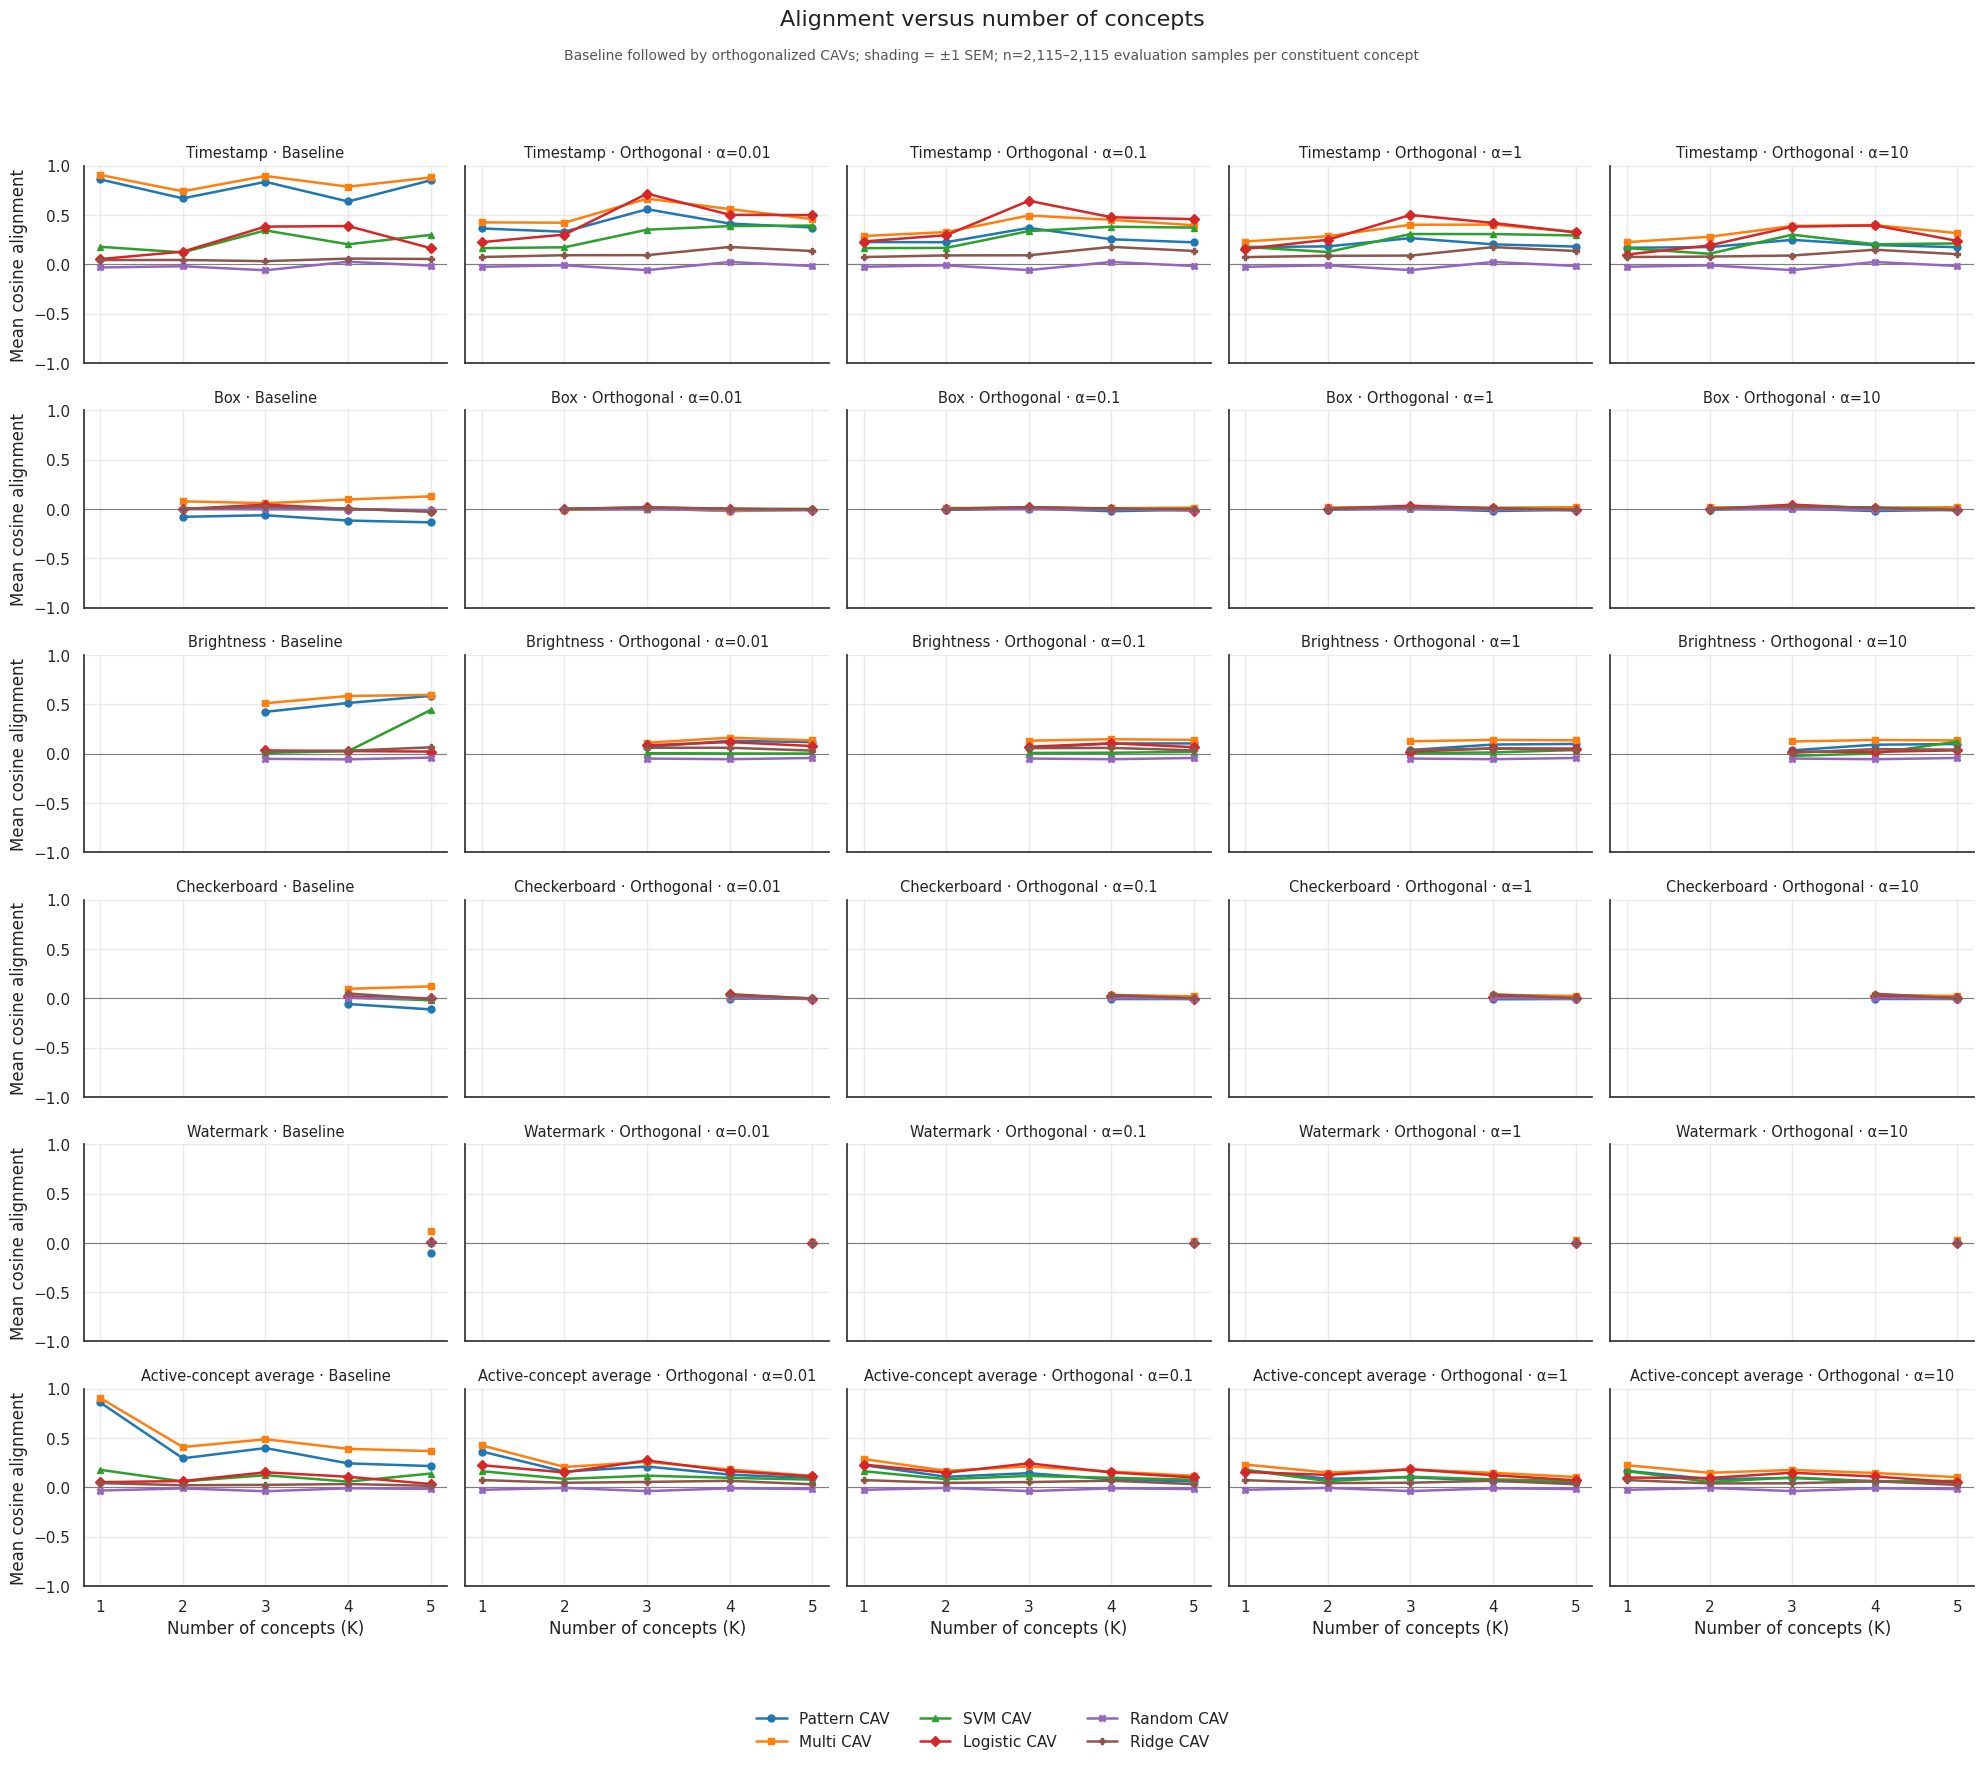

(PosixPath('/home/erogullari/Workspace/cav-disentanglement/media/multi_concept_alignment/alignment_vs_num_concepts.png'),
 PosixPath('/home/erogullari/Workspace/cav-disentanglement/media/multi_concept_alignment/alignment_vs_num_concepts.pdf'))

In [20]:
alignment_vs_k = plot_alignment_vs_num_concepts()
alignment_vs_k["saved_paths"]


### 2. Localization versus number of concepts


The same $K$ sweep is shown for Otsu IoU, mask recall, and concept relevance. The final **Localizable-concept average** row averages the spatial concepts available at each $K$; brightness is omitted because it is global rather than spatially localized. Each metric starts with a Baseline column and then shows the selected Orthogonal alphas.


In [21]:
def plot_localization_vs_num_concepts(
    localization: pd.DataFrame = localization_summary,
    *,
    metrics: Sequence[str] = (
        "otsu_iou",
        "intersection_over_true_mask",
        "concept_relevance",
    ),
    concepts: Sequence[str] | None = None,
    cav_methods: Sequence[str] | None = None,
    alphas: Sequence[float] | None = None,
    mask_variant: str = "raw",
    uncertainty: str | None = "sem",
    y_limits: tuple[float, float] | None = (0.0, 1.0),
    save: bool = True,
    save_dir: Path | str = MEDIA_ROOT,
    filename_prefix: str = "localization_vs_num_concepts",
    formats: Sequence[str] = ("png", "pdf"),
    dpi: int = 300,
) -> dict[str, dict]:
    # Plot requested localization metrics with baseline first; brightness is excluded.
    unknown_metrics = sorted(set(metrics) - set(LOCALIZATION_METRICS))
    if unknown_metrics:
        raise ValueError(f"Unknown localization metrics: {unknown_metrics}")

    selected_data = localization.loc[
        localization["mask_variant"].astype(str).str.casefold().eq(mask_variant.casefold())
        & ~localization["concept"].eq("brightness")
    ].copy()
    concepts = _ordered_values(
        concepts, LOCALIZED_CONCEPT_ORDER, selected_data["concept"].unique()
    )
    cav_methods = _ordered_values(
        cav_methods, CAV_METHOD_ORDER, selected_data["cav_method"].unique()
    )
    selected_data = selected_data.loc[
        selected_data["concept"].isin(LOCALIZED_CONCEPT_ORDER)
        & selected_data["cav_method"].isin(cav_methods)
    ].copy()
    consistency_columns = ["n"]
    for mean_col, sem_col, _ in LOCALIZATION_METRICS.values():
        consistency_columns.extend((mean_col, sem_col))
    plot_data, facet_values, facet_labels, _ = _prepare_baseline_orthogonal_columns(
        selected_data,
        alphas=alphas,
        consistency_columns=consistency_columns,
    )
    plot_data = _append_concept_average(
        plot_data,
        metric_pairs=tuple(
            (mean_col, sem_col)
            for mean_col, sem_col, _ in LOCALIZATION_METRICS.values()
        ),
        average_concept=LOCALIZABLE_CONCEPT_AVERAGE,
    )
    plot_concepts = [*concepts, LOCALIZABLE_CONCEPT_AVERAGE]
    plot_data = plot_data.loc[plot_data["concept"].isin(plot_concepts)].copy()

    results: dict[str, dict] = {}
    for metric in metrics:
        mean_col, sem_col, metric_label = LOCALIZATION_METRICS[metric]
        figure = _plot_trend_grid(
            plot_data,
            mean_col=mean_col,
            sem_col=sem_col,
            metric_label=metric_label,
            title=f"Localization versus number of concepts · {metric_label}",
            concepts=plot_concepts,
            cav_methods=cav_methods,
            facet_values=facet_values,
            variant_note="Baseline followed by orthogonalized CAVs",
            facet_col="cav_column",
            facet_labels=facet_labels,
            uncertainty=uncertainty,
            y_limits=y_limits,
        )
        saved_paths = save_figure(
            figure,
            f"{filename_prefix}_{metric}_{mask_variant}",
            save=save,
            save_dir=save_dir,
            formats=formats,
            dpi=dpi,
        )
        plt.show()
        results[metric] = {
            "figure": figure,
            "data": plot_data.copy(),
            "saved_paths": saved_paths,
        }
    return results


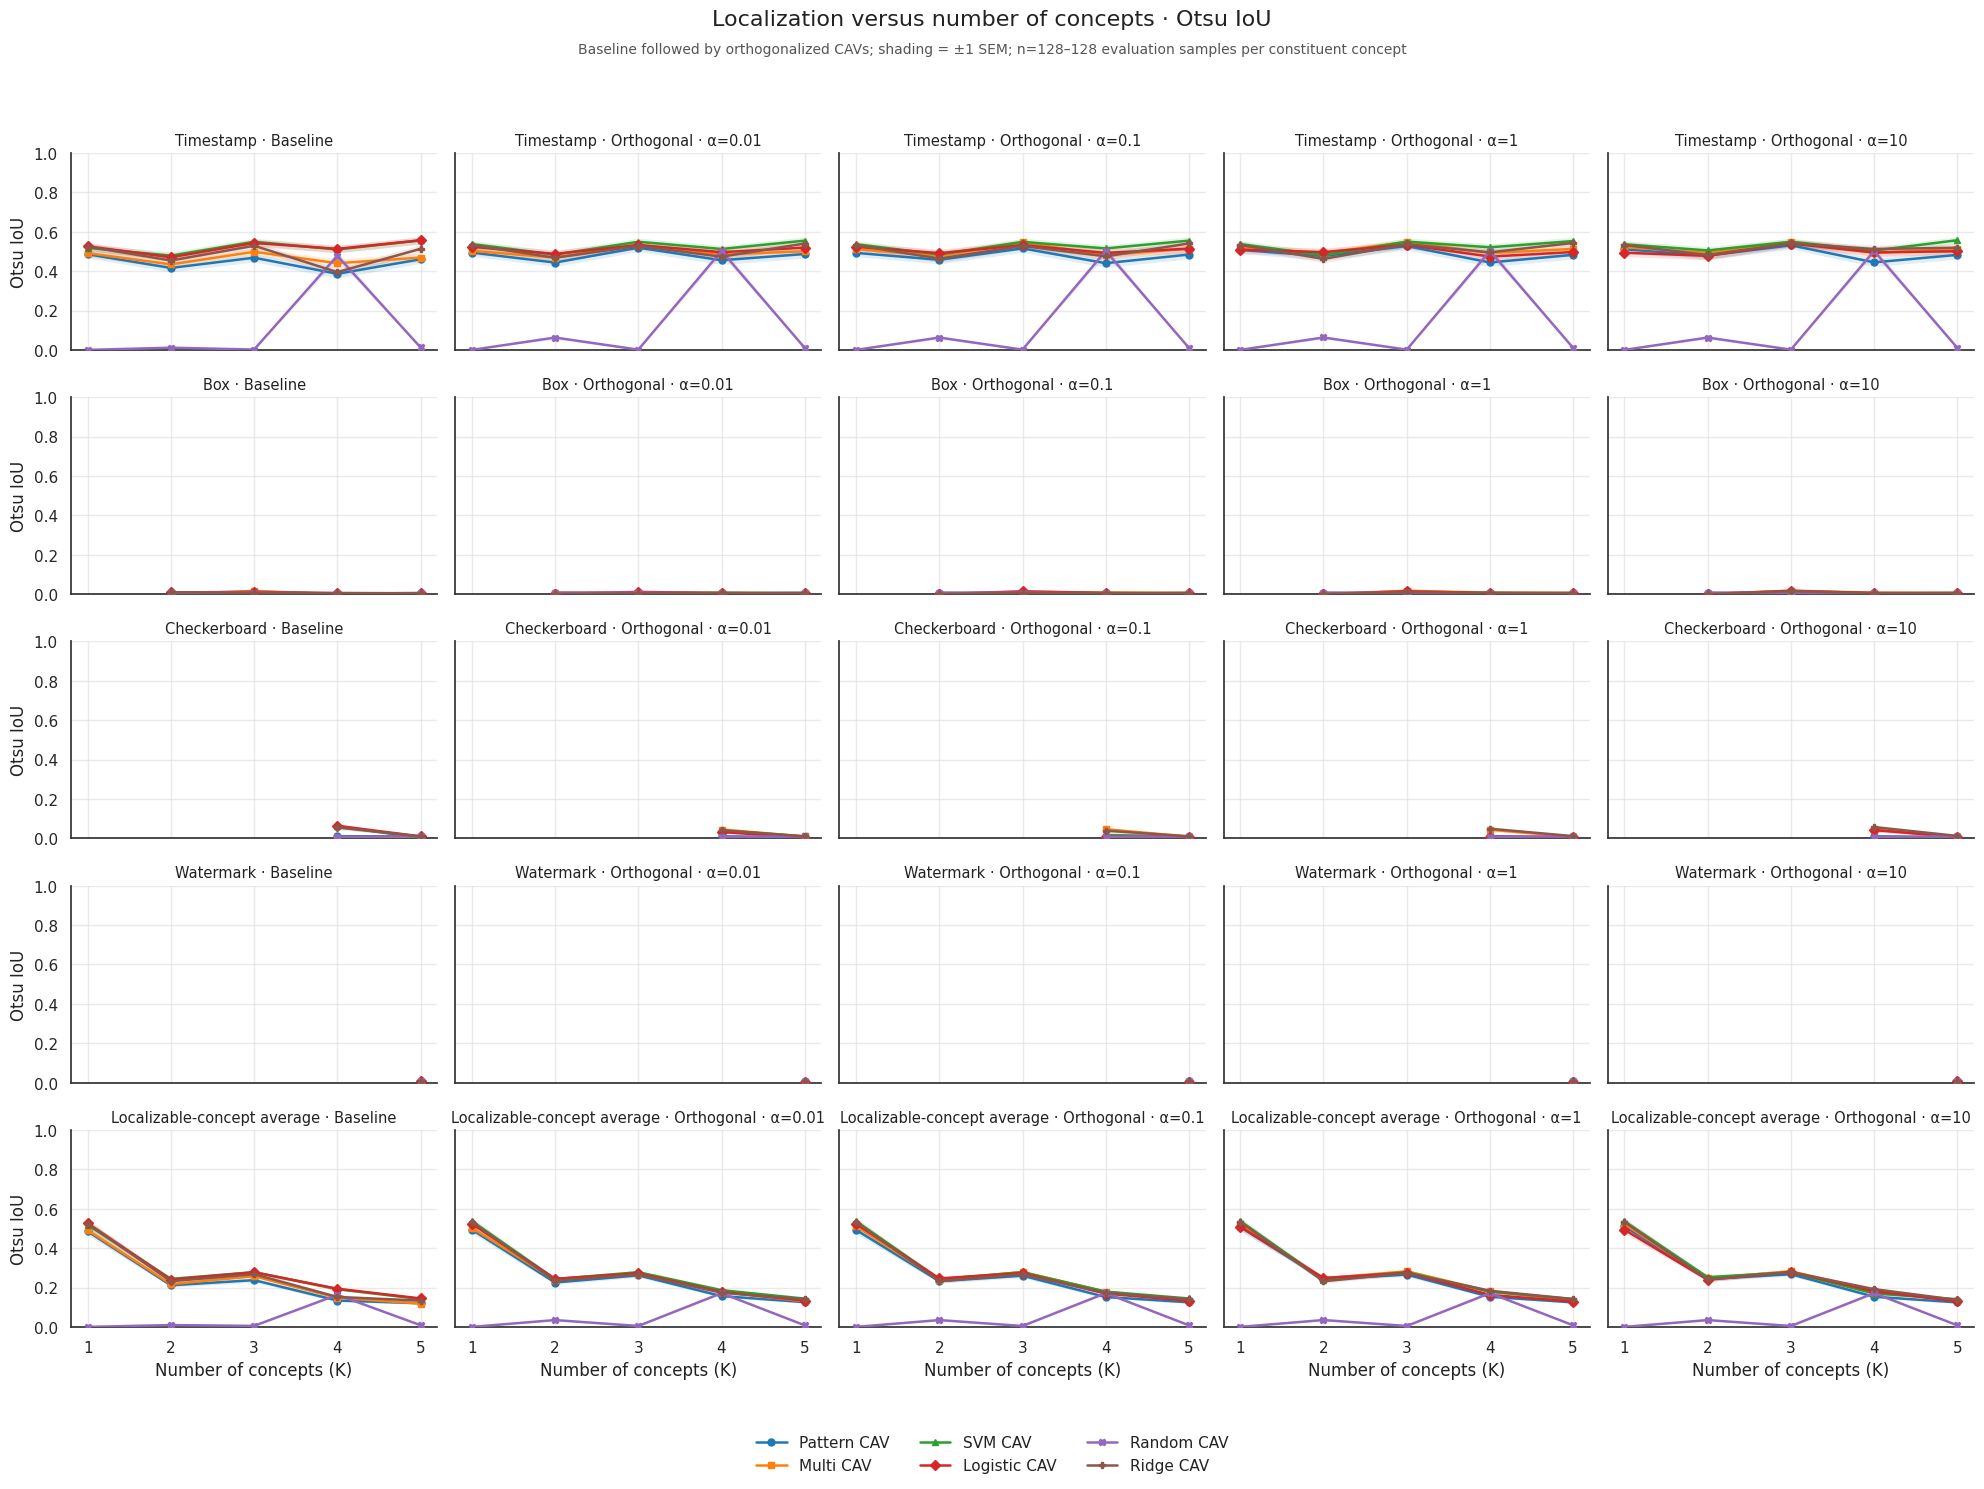

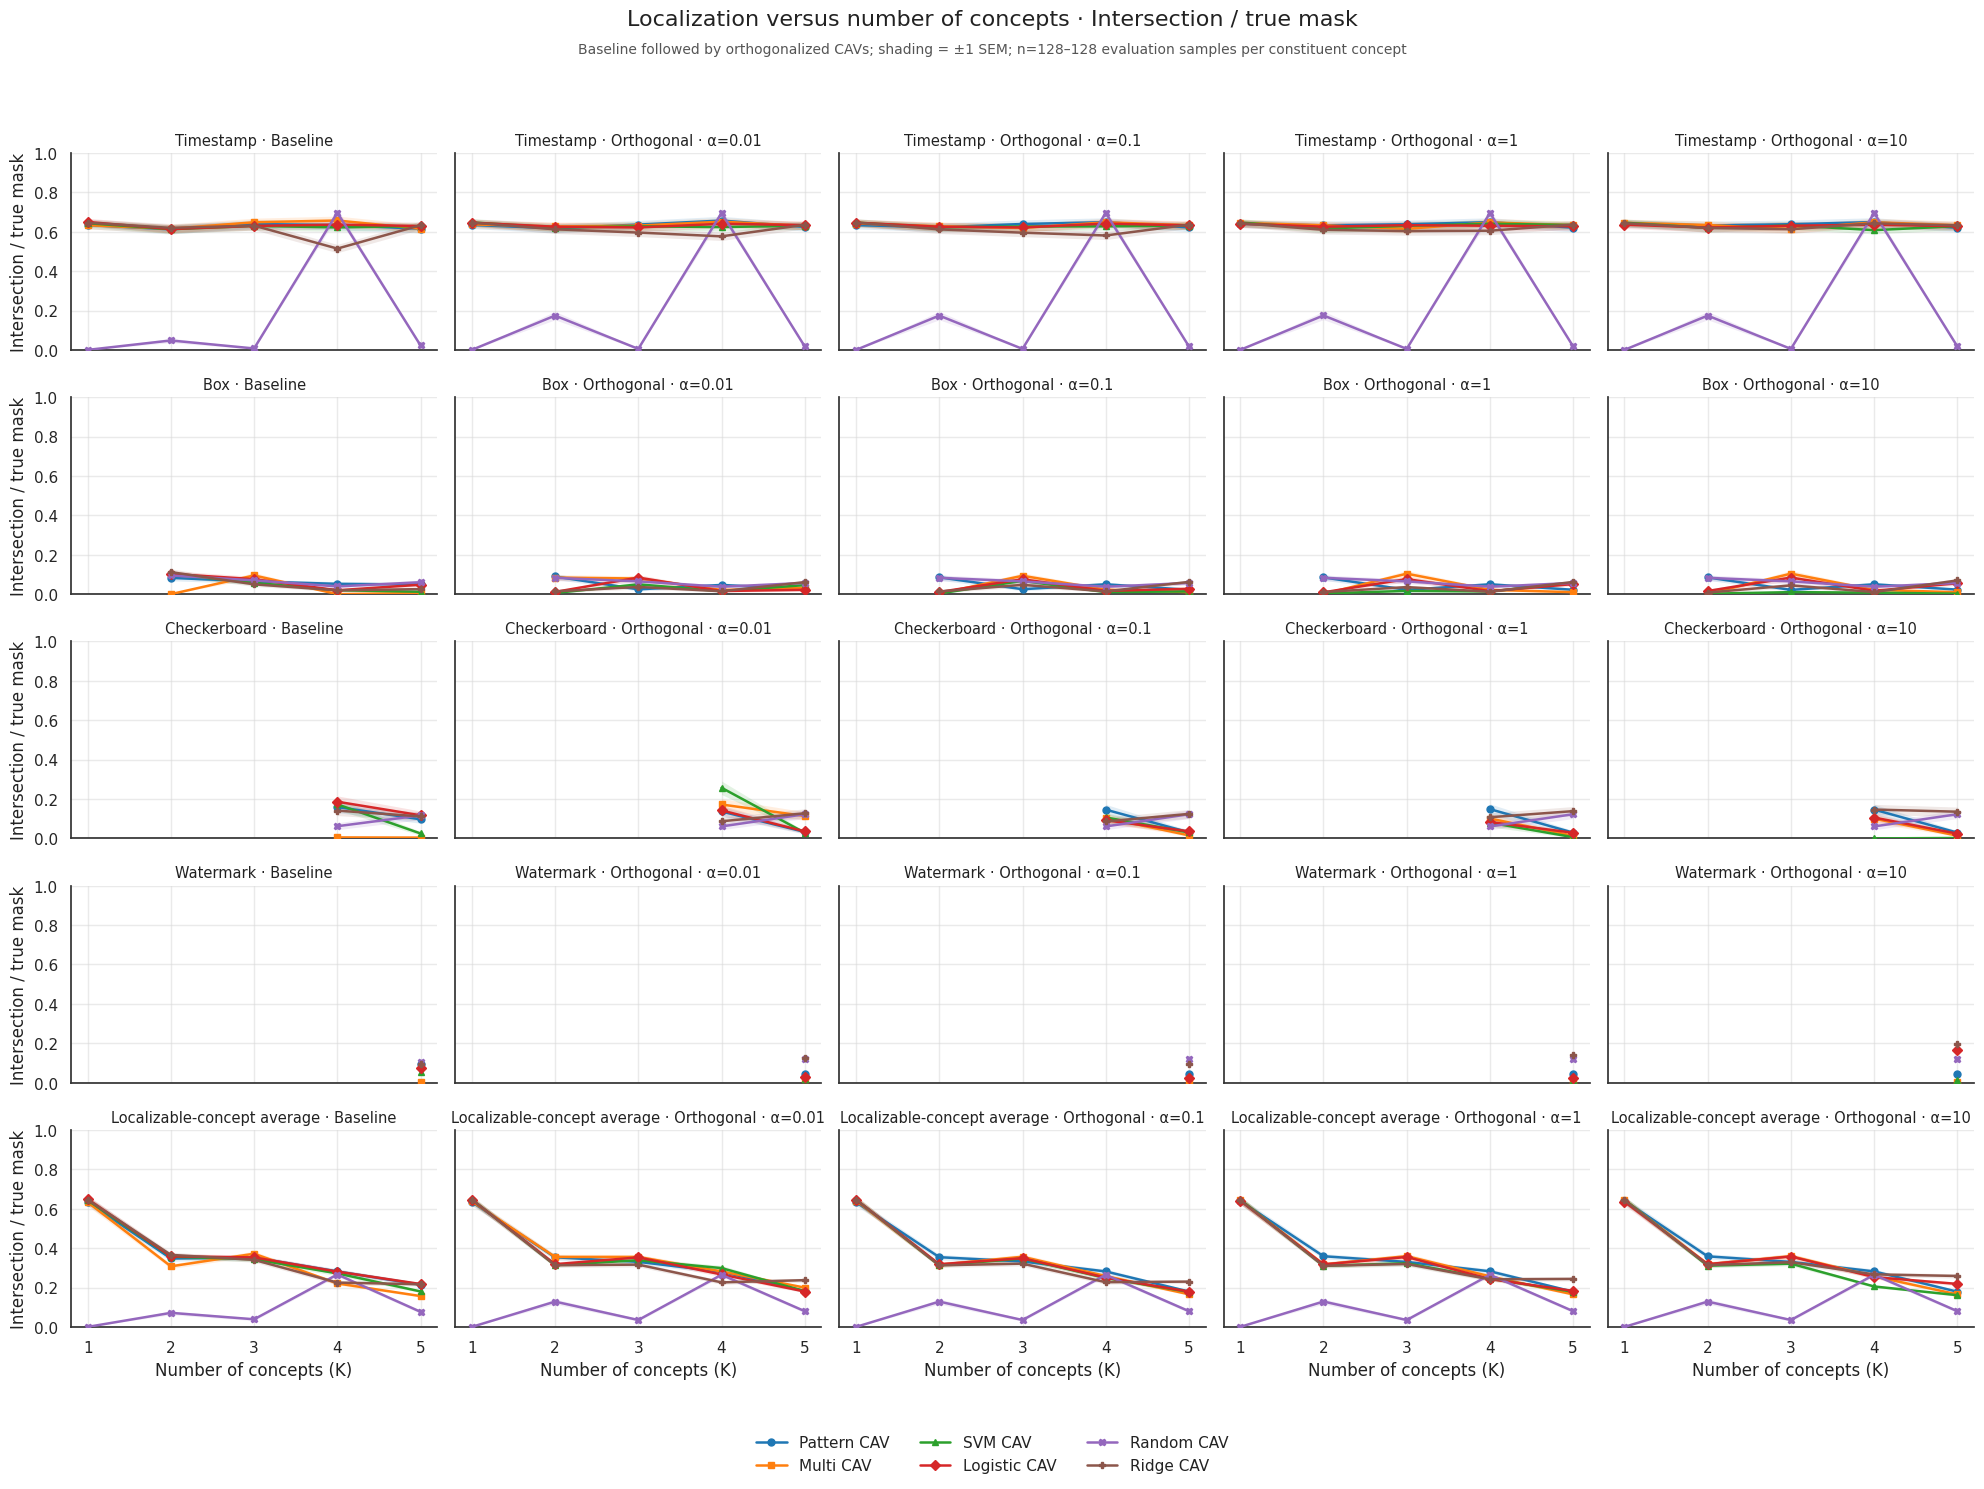

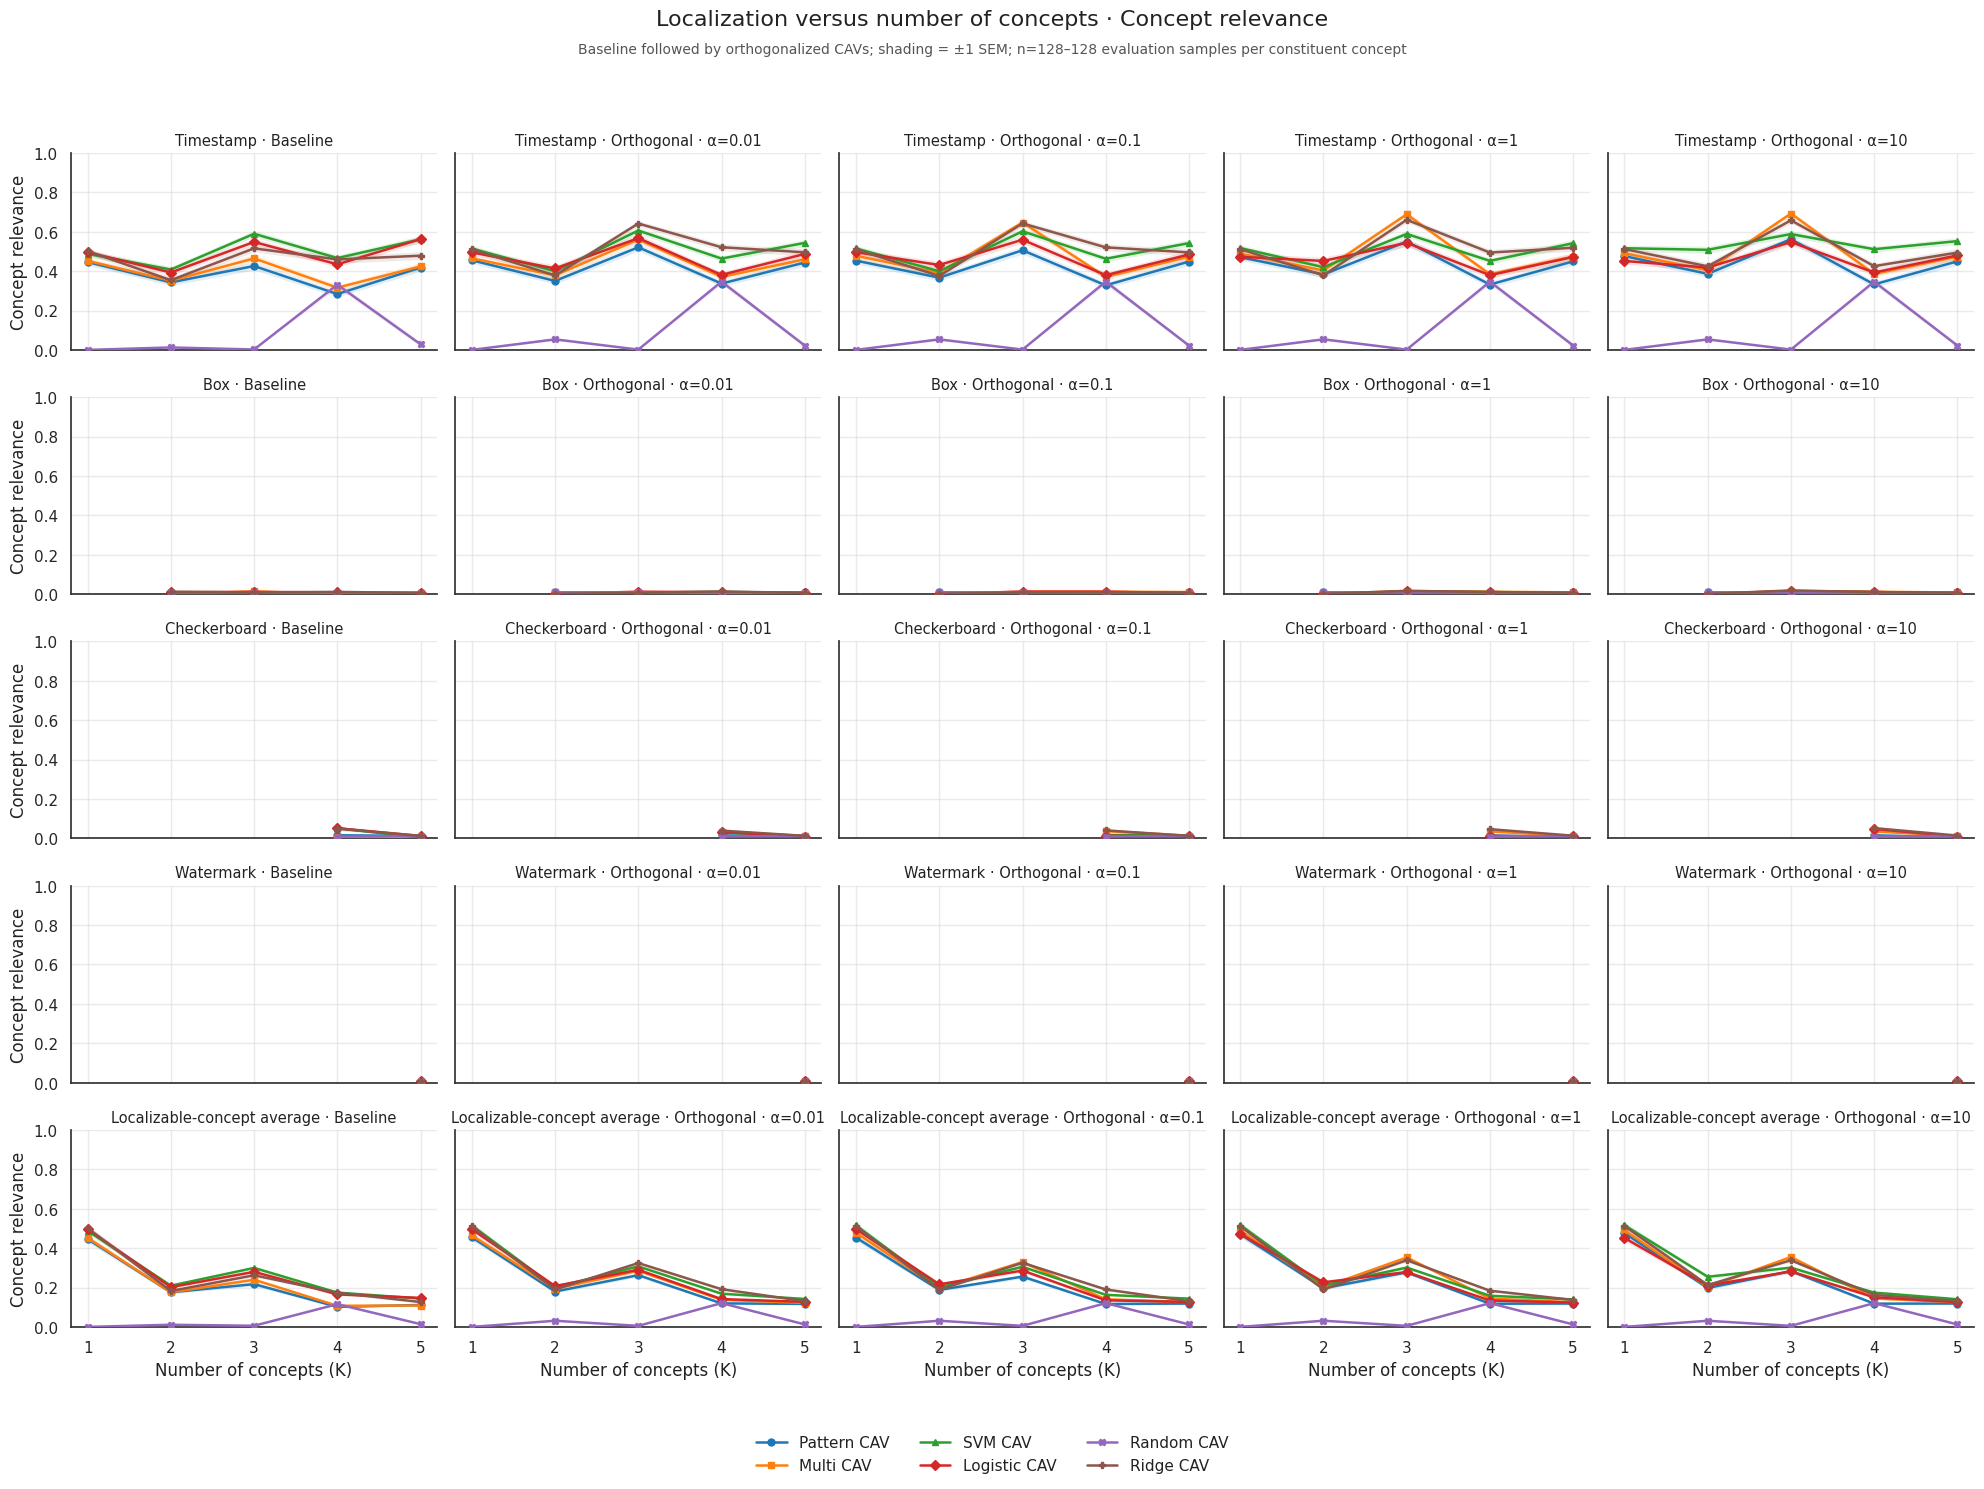

{'otsu_iou': (PosixPath('/home/erogullari/Workspace/cav-disentanglement/media/multi_concept_alignment/localization_vs_num_concepts_otsu_iou_raw.png'),
  PosixPath('/home/erogullari/Workspace/cav-disentanglement/media/multi_concept_alignment/localization_vs_num_concepts_otsu_iou_raw.pdf')),
 'intersection_over_true_mask': (PosixPath('/home/erogullari/Workspace/cav-disentanglement/media/multi_concept_alignment/localization_vs_num_concepts_intersection_over_true_mask_raw.png'),
  PosixPath('/home/erogullari/Workspace/cav-disentanglement/media/multi_concept_alignment/localization_vs_num_concepts_intersection_over_true_mask_raw.pdf')),
 'concept_relevance': (PosixPath('/home/erogullari/Workspace/cav-disentanglement/media/multi_concept_alignment/localization_vs_num_concepts_concept_relevance_raw.png'),
  PosixPath('/home/erogullari/Workspace/cav-disentanglement/media/multi_concept_alignment/localization_vs_num_concepts_concept_relevance_raw.pdf'))}

In [22]:
localization_vs_k = plot_localization_vs_num_concepts()
{metric: result["saved_paths"] for metric, result in localization_vs_k.items()}


### 3. Performance change relative to concept introduction


Each concept–method series is re-zeroed at its first available $K$. The final overview row first averages the concepts available at each $K$, then subtracts that overview's $K=1$ value, so it shows the overall change as concepts are added. The Baseline change is shown first, followed by the same calculation for every selected Orthogonal alpha.


In [23]:
def plot_performance_change_from_introduction(
    summary: pd.DataFrame,
    *,
    mean_col: str,
    sem_col: str,
    metric_label: str,
    concepts: Sequence[str] | None = None,
    cav_methods: Sequence[str] | None = None,
    alphas: Sequence[float] | None = None,
    mask_variant: str | None = None,
    exclude_concepts: Sequence[str] = (),
    uncertainty: str | None = "sem",
    y_limits: tuple[float, float] | None = None,
    save: bool = True,
    save_dir: Path | str = MEDIA_ROOT,
    filename: str = "performance_change_from_introduction",
    formats: Sequence[str] = ("png", "pdf"),
    dpi: int = 300,
) -> dict:
    # Plot score(K) - score(K_first), with baseline before orthogonalized alphas.
    _require_columns(
        summary,
        (
            "num_concepts", "concept", "cav_method", "alpha", "cav_variant",
            "n", mean_col, sem_col,
        ),
        metric_label,
    )
    selected_data = summary.loc[
        ~summary["concept"].isin(exclude_concepts)
    ].copy()
    is_localization = "mask_variant" in selected_data
    if is_localization:
        effective_mask_variant = "raw" if mask_variant is None else mask_variant
        selected_data = selected_data.loc[
            selected_data["mask_variant"].astype(str).str.casefold().eq(
                effective_mask_variant.casefold()
            )
        ].copy()

    preferred_concepts = (
        LOCALIZED_CONCEPT_ORDER if is_localization else CONCEPT_ORDER
    )
    concepts = _ordered_values(
        concepts, preferred_concepts, selected_data["concept"].unique()
    )
    cav_methods = _ordered_values(
        cav_methods, CAV_METHOD_ORDER, selected_data["cav_method"].unique()
    )
    selected_data = selected_data.loc[
        selected_data["concept"].isin(preferred_concepts)
        & selected_data["cav_method"].isin(cav_methods)
    ].copy()
    plot_data, facet_values, facet_labels, _ = _prepare_baseline_orthogonal_columns(
        selected_data,
        alphas=alphas,
        consistency_columns=("n", mean_col, sem_col),
    )
    average_concept = (
        LOCALIZABLE_CONCEPT_AVERAGE if is_localization else ACTIVE_CONCEPT_AVERAGE
    )
    plot_data = _append_concept_average(
        plot_data,
        metric_pairs=((mean_col, sem_col),),
        average_concept=average_concept,
    )
    plot_concepts = [*concepts, average_concept]
    plot_data = plot_data.loc[plot_data["concept"].isin(plot_concepts)].copy()

    group_columns = ["concept", "cav_method", "cav_column"]
    first_rows = (
        plot_data.sort_values("num_concepts")
        .groupby(group_columns, as_index=False, observed=True)
        .first()[[*group_columns, "num_concepts", mean_col, sem_col]]
        .rename(
            columns={
                "num_concepts": "first_k",
                mean_col: "first_score",
                sem_col: "first_sem",
            }
        )
    )
    plot_data = plot_data.merge(
        first_rows, on=group_columns, how="left", validate="many_to_one"
    )
    plot_data["score_delta"] = plot_data[mean_col] - plot_data["first_score"]
    plot_data["score_delta_sem"] = np.sqrt(
        plot_data[sem_col].fillna(0.0) ** 2 + plot_data["first_sem"].fillna(0.0) ** 2
    )
    plot_data.loc[
        plot_data["num_concepts"].eq(plot_data["first_k"]), "score_delta_sem"
    ] = 0.0

    figure = _plot_trend_grid(
        plot_data,
        mean_col="score_delta",
        sem_col="score_delta_sem",
        metric_label=f"Δ {metric_label}",
        title=f"Change from concept introduction · {metric_label}",
        concepts=plot_concepts,
        cav_methods=cav_methods,
        facet_values=facet_values,
        variant_note="Baseline followed by orthogonalized CAVs",
        facet_col="cav_column",
        facet_labels=facet_labels,
        uncertainty=uncertainty,
        y_limits=y_limits,
    )
    saved_paths = save_figure(
        figure,
        filename,
        save=save,
        save_dir=save_dir,
        formats=formats,
        dpi=dpi,
    )
    plt.show()
    return {"figure": figure, "data": plot_data, "saved_paths": saved_paths}


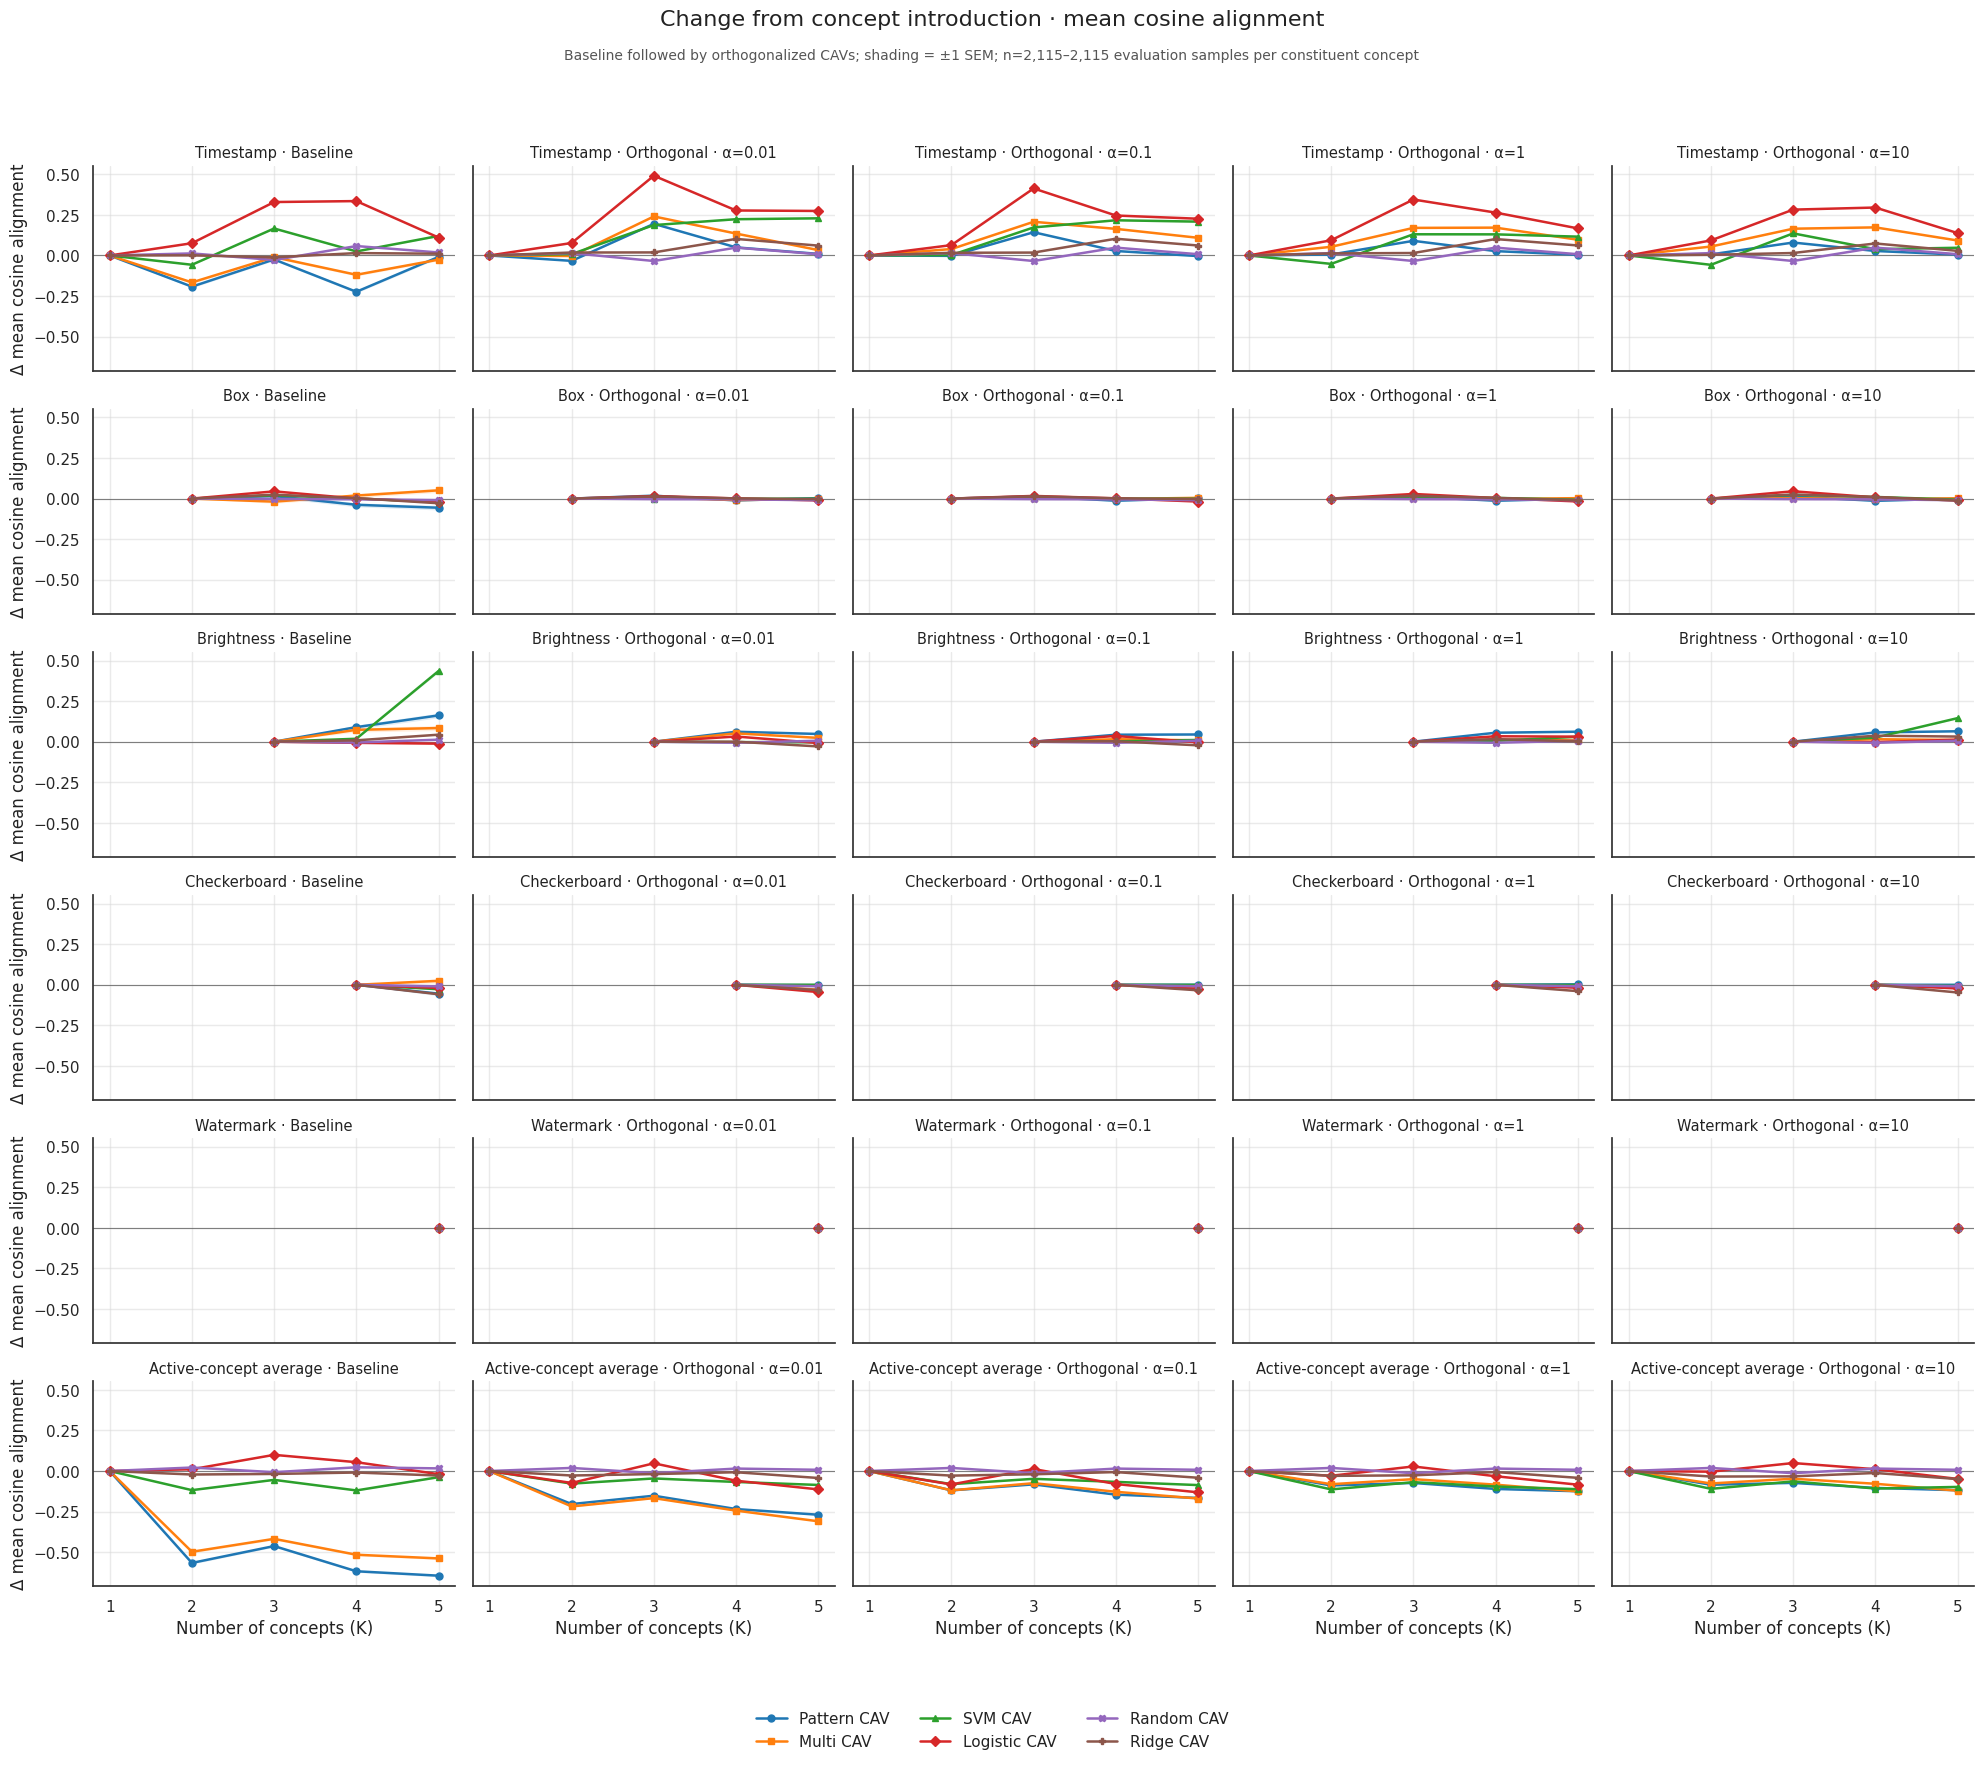

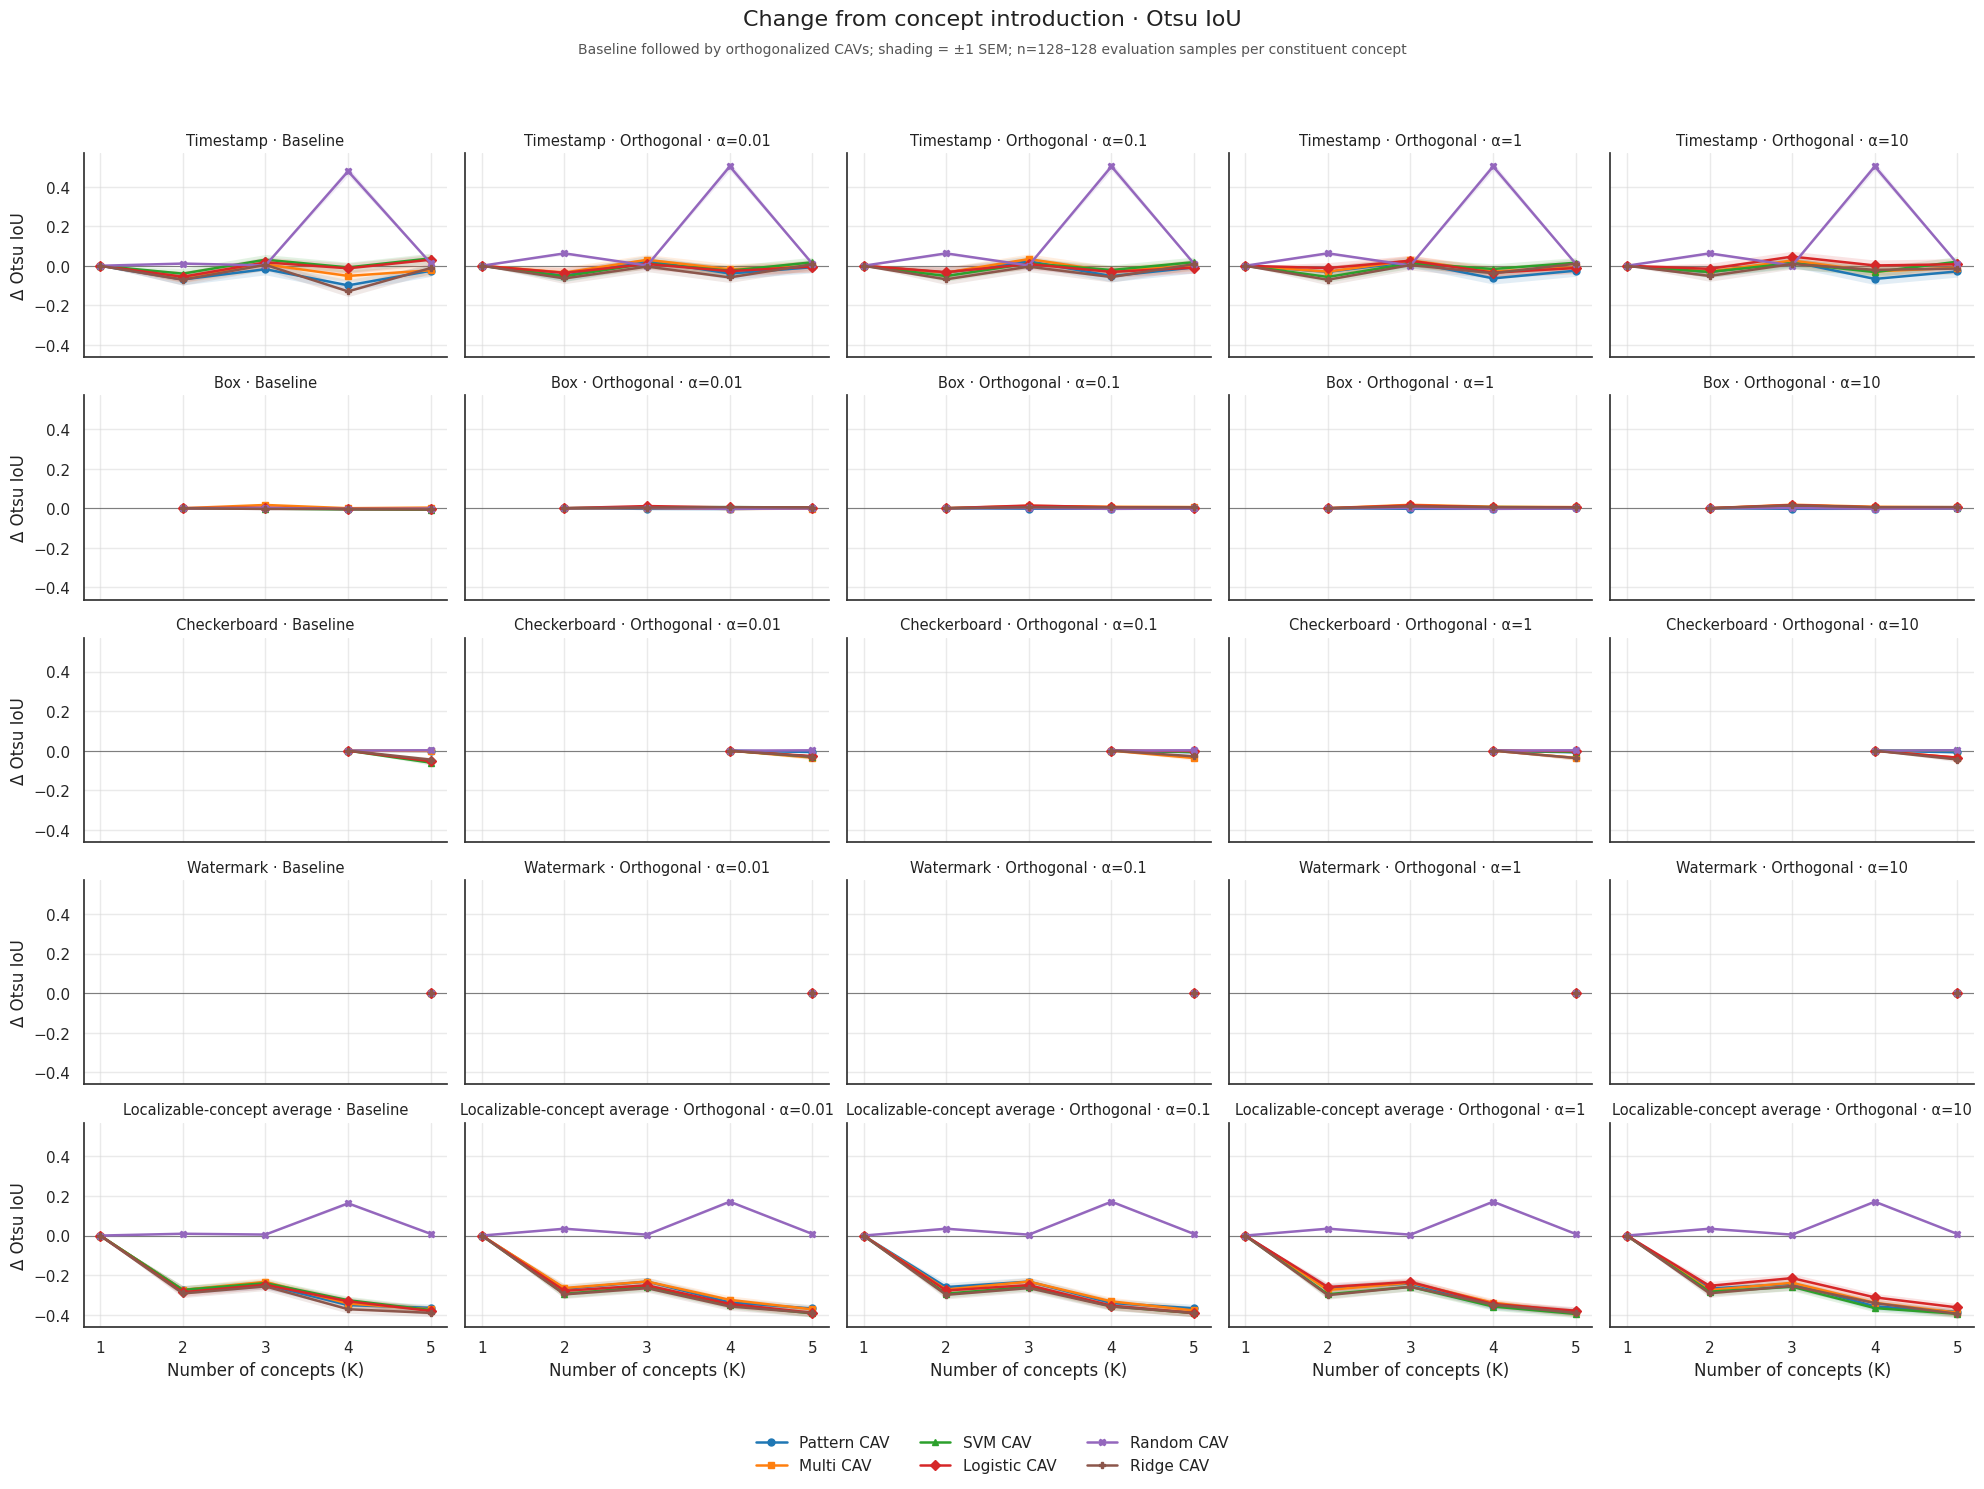

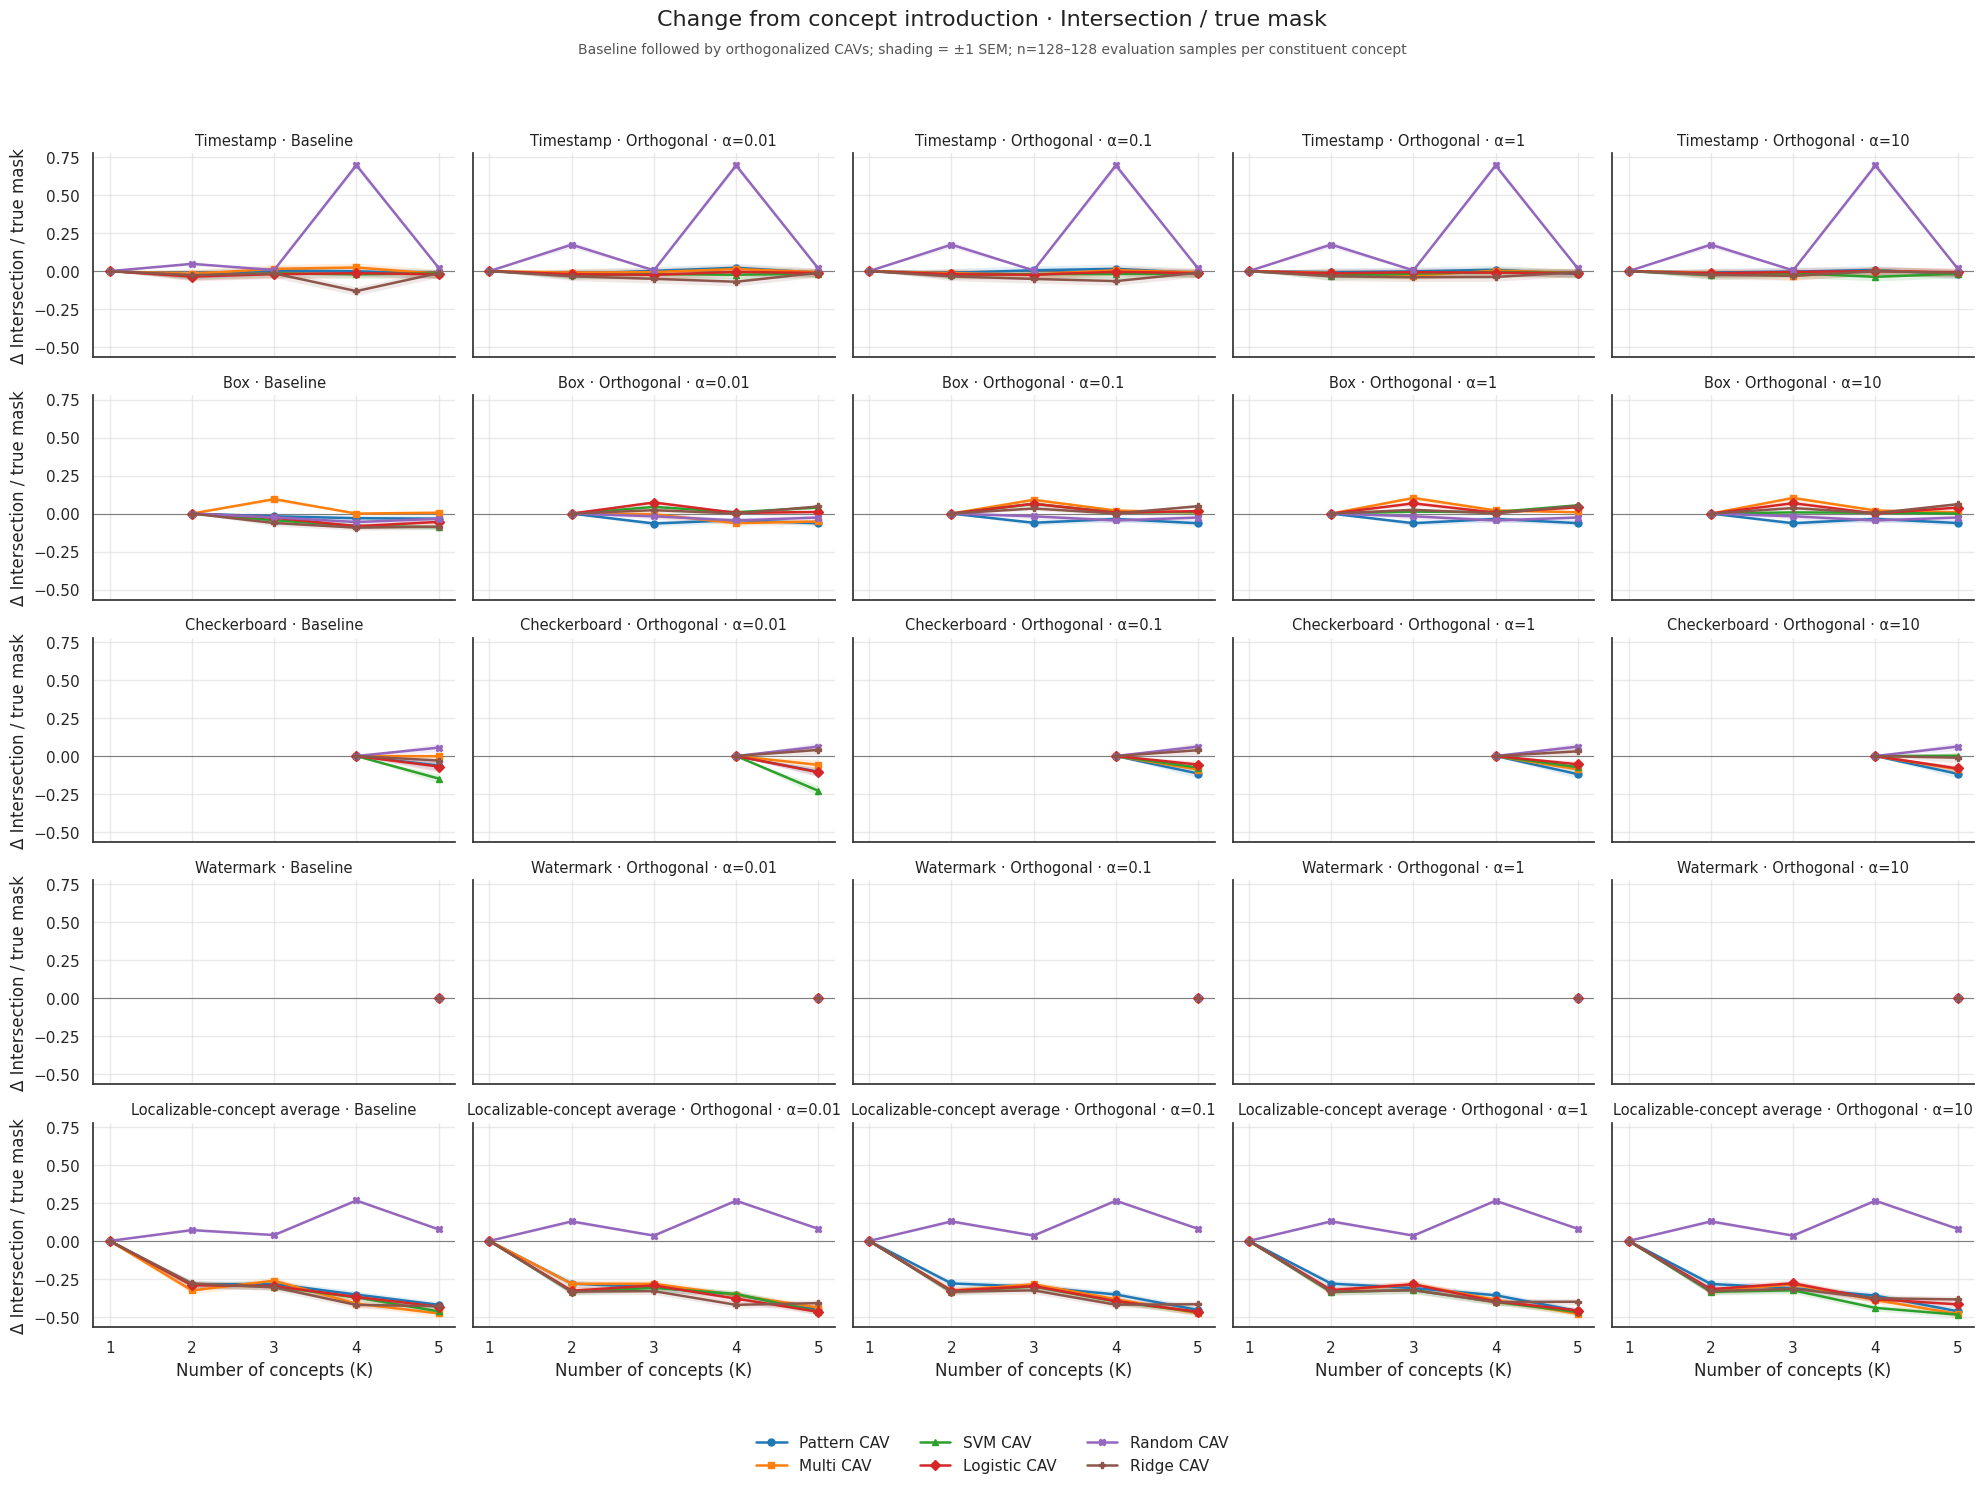

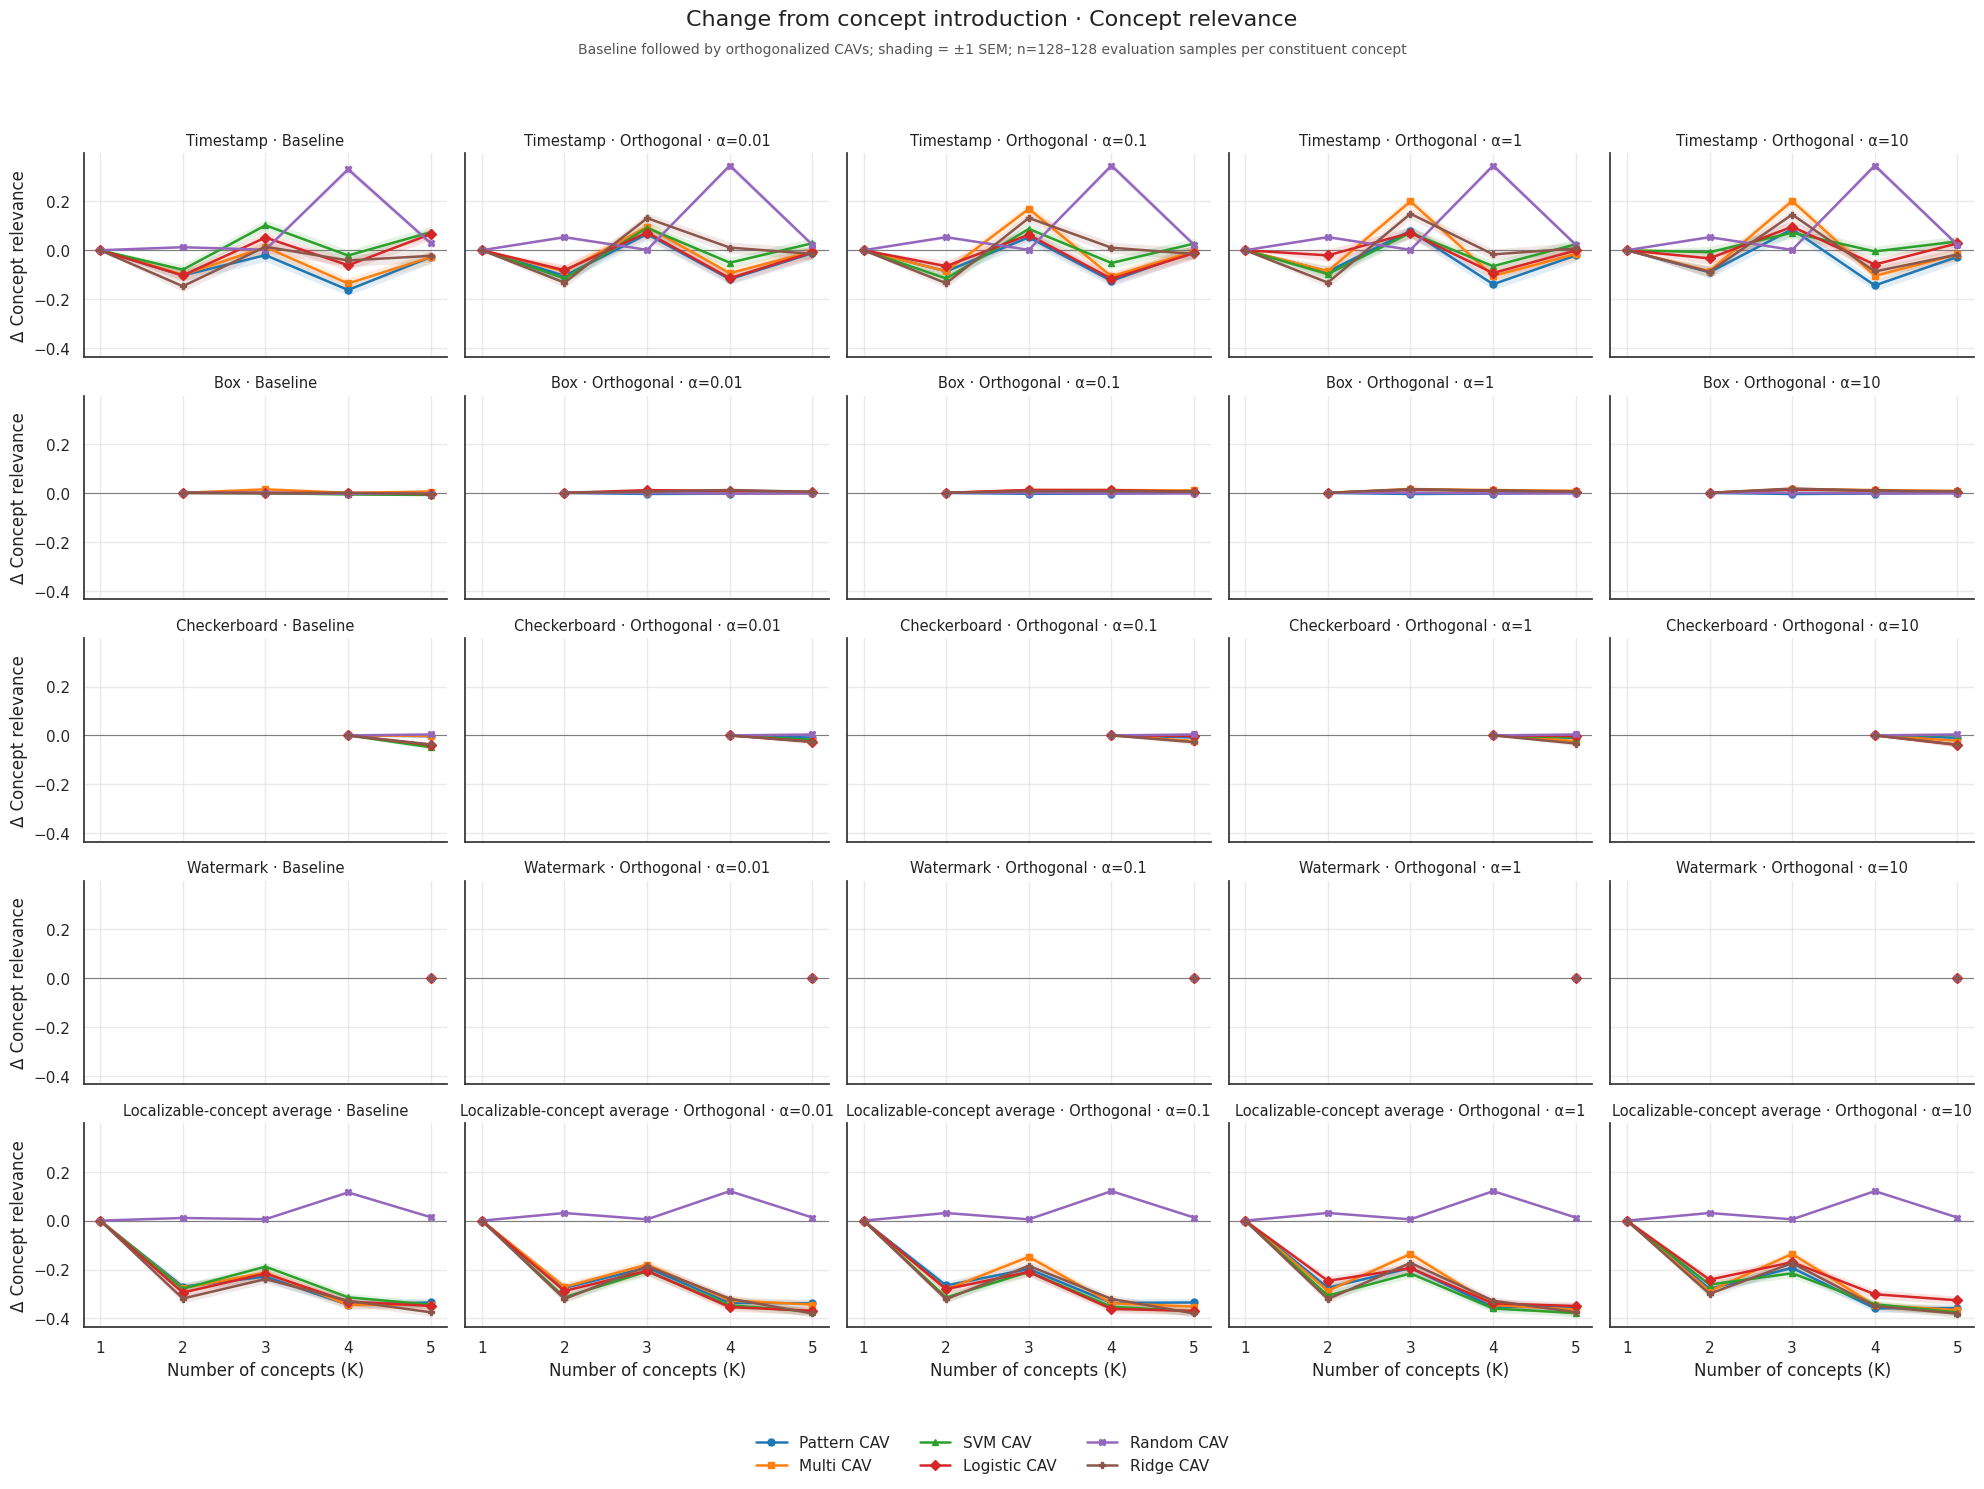

In [24]:
alignment_change = plot_performance_change_from_introduction(
    alignment_summary,
    mean_col="cosine_mean",
    sem_col="cosine_sem",
    metric_label="mean cosine alignment",
    filename="alignment_change_from_introduction",
)

localization_changes = {}
for metric, (mean_col, sem_col, metric_label) in LOCALIZATION_METRICS.items():
    localization_changes[metric] = plot_performance_change_from_introduction(
        localization_summary,
        mean_col=mean_col,
        sem_col=sem_col,
        metric_label=metric_label,
        mask_variant="raw",
        exclude_concepts=("brightness",),
        filename=f"localization_change_from_introduction_{metric}_raw",
    )


### 4. Alignment–localization trade-off


Each point joins alignment and localization for one concept, method, and $K$. The Baseline facet comes first, followed by the selected Orthogonal alphas; color encodes $K$ and marker shape encodes the CAV method.


In [25]:
def plot_alignment_localization_tradeoff(
    alignment: pd.DataFrame = alignment_summary,
    localization: pd.DataFrame = localization_summary,
    *,
    localization_metric: str = "otsu_iou",
    concepts: Sequence[str] | None = None,
    cav_methods: Sequence[str] | None = None,
    alphas: Sequence[float] | None = None,
    mask_variant: str = "raw",
    annotate_concepts: bool = False,
    x_limits: tuple[float, float] | None = (-1.0, 1.0),
    y_limits: tuple[float, float] | None = (0.0, 1.0),
    save: bool = True,
    save_dir: Path | str = MEDIA_ROOT,
    filename: str | None = None,
    formats: Sequence[str] = ("png", "pdf"),
    dpi: int = 300,
) -> dict:
    # Join alignment and localization means, with baseline before orthogonalized alphas.
    if localization_metric not in LOCALIZATION_METRICS:
        raise ValueError(
            f"Unknown localization metric '{localization_metric}'. "
            f"Choose from {sorted(LOCALIZATION_METRICS)}."
        )
    localization_mean, localization_sem, localization_label = LOCALIZATION_METRICS[
        localization_metric
    ]
    localization_data = localization.loc[
        localization["mask_variant"].astype(str).str.casefold().eq(mask_variant.casefold())
        & ~localization["concept"].eq("brightness")
    ].copy()

    concepts = _ordered_values(
        concepts, LOCALIZED_CONCEPT_ORDER, localization_data["concept"].unique()
    )
    cav_methods = _ordered_values(
        cav_methods, CAV_METHOD_ORDER, localization_data["cav_method"].unique()
    )
    alignment_data = alignment.loc[
        alignment["concept"].isin(concepts)
        & alignment["cav_method"].isin(cav_methods)
    ].copy()
    localization_data = localization_data.loc[
        localization_data["concept"].isin(concepts)
        & localization_data["cav_method"].isin(cav_methods)
    ].copy()

    alignment_data, facet_values, facet_labels, selected_alphas = (
        _prepare_baseline_orthogonal_columns(
            alignment_data,
            alphas=alphas,
            consistency_columns=("n", "cosine_mean", "cosine_sem", "cosine_mean_delta"),
        )
    )
    localization_data, localization_facets, _, _ = _prepare_baseline_orthogonal_columns(
        localization_data,
        alphas=selected_alphas,
        consistency_columns=("n", localization_mean, localization_sem),
    )
    if facet_values != localization_facets:
        raise ValueError("Alignment and localization CAV-variant columns do not match.")

    join_columns = [
        "variant_id", "num_concepts", "concept", "cav_method", "cav_column"
    ]
    tradeoff_data = alignment_data[
        [*join_columns, "cosine_mean", "cosine_sem", "n"]
    ].rename(columns={"n": "alignment_n"}).merge(
        localization_data[
            [*join_columns, localization_mean, "n"]
        ].rename(
            columns={
                localization_mean: "localization_score",
                "n": "localization_n",
            }
        ),
        on=join_columns,
        how="inner",
        validate="one_to_one",
    )
    if tradeoff_data.empty:
        raise ValueError("No matching alignment/localization rows were found.")

    figure, axes = plt.subplots(
        1,
        len(facet_values),
        figsize=(4.25 * len(facet_values), 5.5),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    for column_index, facet_value in enumerate(facet_values):
        axis = axes[0, column_index]
        panel = tradeoff_data.loc[tradeoff_data["cav_column"].eq(facet_value)]
        for method in cav_methods:
            series = panel.loc[panel["cav_method"].eq(method)]
            if series.empty:
                continue
            point_colors = [K_COLORS[int(k)] for k in series["num_concepts"]]
            axis.scatter(
                series["cosine_mean"],
                series["localization_score"],
                c=point_colors,
                marker=METHOD_MARKERS.get(method, "o"),
                s=62,
                alpha=0.86,
                edgecolors="white",
                linewidths=0.55,
                zorder=3,
            )
            if annotate_concepts:
                for row in series.itertuples():
                    axis.annotate(
                        CONCEPT_LABELS.get(row.concept, row.concept),
                        (row.cosine_mean, row.localization_score),
                        xytext=(3, 3),
                        textcoords="offset points",
                        fontsize=7,
                        color="#444444",
                    )
        axis.axvline(0.0, color="#555555", linewidth=0.8, alpha=0.65)
        axis.set_title(facet_labels[facet_value])
        axis.set_xlabel("Mean cosine alignment")
        if column_index == 0:
            axis.set_ylabel(localization_label)
        if x_limits is not None:
            axis.set_xlim(*x_limits)
        if y_limits is not None:
            axis.set_ylim(*y_limits)

    alignment_n = tradeoff_data["alignment_n"].astype(int)
    localization_n = tradeoff_data["localization_n"].astype(int)
    figure.suptitle(
        f"Alignment–localization trade-off · {localization_label}",
        fontsize=16,
        y=0.995,
    )
    figure.text(
        0.5,
        0.953,
        (
            f"Baseline first; one point per K × concept × method; alignment n="
            f"{alignment_n.min():,}–{alignment_n.max():,}, localization n="
            f"{localization_n.min():,}–{localization_n.max():,} per point"
        ),
        ha="center",
        va="top",
        fontsize=9.5,
        color="#555555",
    )

    k_handles = [
        Line2D(
            [0], [0], marker="o", linestyle="", markerfacecolor=K_COLORS[k],
            markeredgecolor="white", markersize=7, label=f"K={k}",
        )
        for k in sorted(tradeoff_data["num_concepts"].unique())
    ]
    method_handles = [
        Line2D(
            [0], [0], marker=METHOD_MARKERS.get(method, "o"), linestyle="",
            markerfacecolor="#777777", markeredgecolor="white", markersize=7,
            label=METHOD_LABELS.get(method, method),
        )
        for method in cav_methods
    ]
    k_legend = figure.legend(
        handles=k_handles,
        title="Concept count",
        loc="lower center",
        bbox_to_anchor=(0.30, 0.005),
        ncol=len(k_handles),
        frameon=False,
    )
    figure.add_artist(k_legend)
    figure.legend(
        handles=method_handles,
        title="CAV method",
        loc="lower center",
        bbox_to_anchor=(0.72, 0.005),
        ncol=3,
        frameon=False,
    )
    figure.tight_layout(rect=(0.0, 0.15, 1.0, 0.91))

    filename = filename or f"alignment_localization_tradeoff_{localization_metric}_{mask_variant}"
    saved_paths = save_figure(
        figure,
        filename,
        save=save,
        save_dir=save_dir,
        formats=formats,
        dpi=dpi,
    )
    plt.show()
    return {"figure": figure, "data": tradeoff_data, "saved_paths": saved_paths}


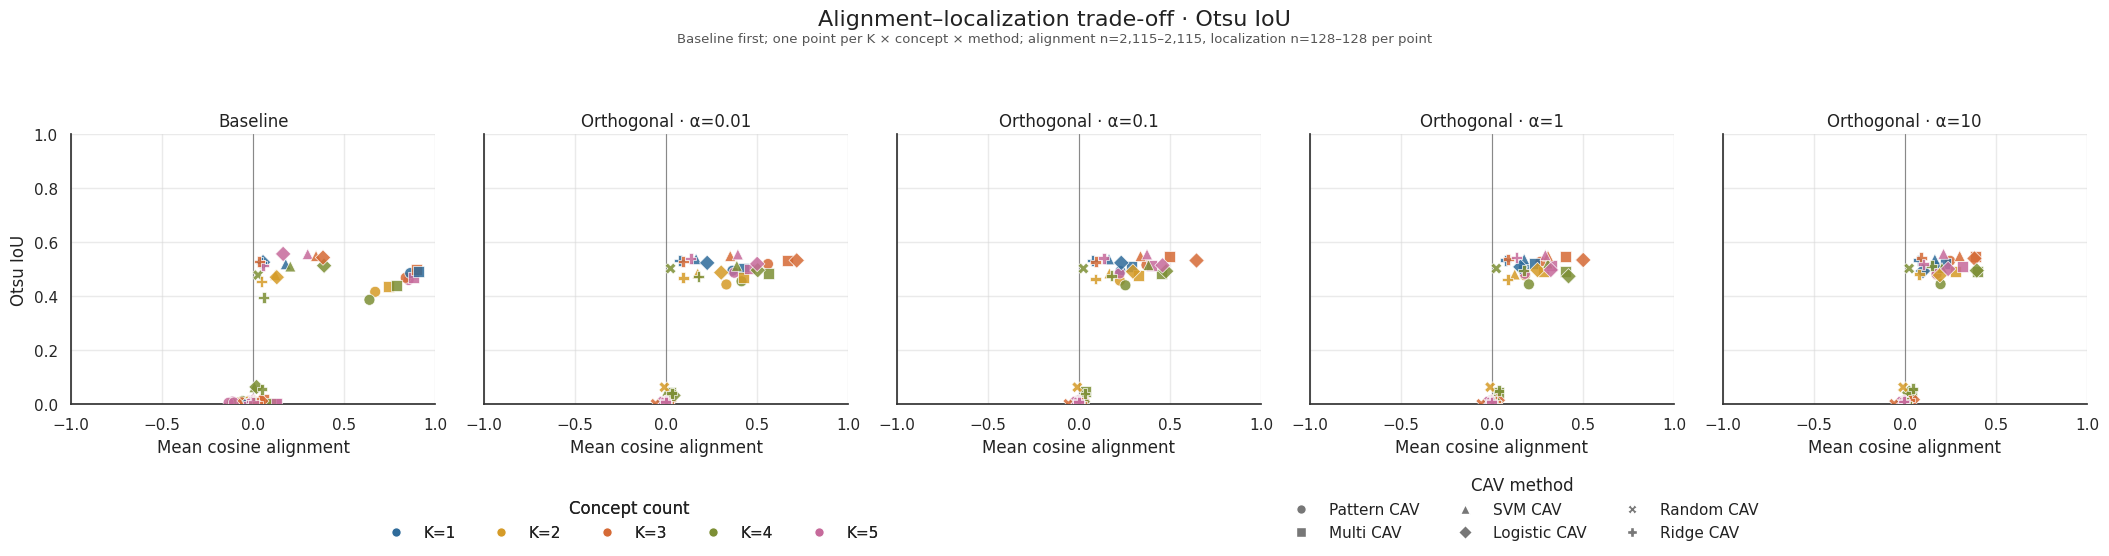

(PosixPath('/home/erogullari/Workspace/cav-disentanglement/media/multi_concept_alignment/alignment_localization_tradeoff_otsu_iou_raw.png'),
 PosixPath('/home/erogullari/Workspace/cav-disentanglement/media/multi_concept_alignment/alignment_localization_tradeoff_otsu_iou_raw.pdf'))

In [26]:
alignment_localization_tradeoff = plot_alignment_localization_tradeoff(
    localization_metric="otsu_iou",
    mask_variant="raw",
)
alignment_localization_tradeoff["saved_paths"]


## Notes

Every faceted visualization puts the verified, deduplicated Baseline in column one and the selected Orthogonal alphas in the remaining columns. In the first three sections, the final row is the arithmetic mean of the concepts available at each $K$; its SEM is propagated as $\sqrt{\sum_i SEM_i^2}/m$ for $m$ constituent concepts. Alignment includes brightness at $K=3$, while localization excludes brightness and therefore averages only concepts with spatial masks. Pass `mask_variant="dilated_3px"` for supported dilated masks, or a subset of `alphas`, `cav_methods`, and `concepts` to the plotting functions. Set `save=False` to preview without exporting.
